## Setup

### Imports

In [1]:
%load_ext autoreload
%autoreload 2
import os
from os.path import join as ospj
from glob import glob

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm
from einops import rearrange
import itertools

from config import CONFIG
from model_v5 import MultivarWav2Vec2
from model_wrapper import ModelV3WrapperWithQueue
from dataset import SzDatasetRegsFull
from model_config import MODEL_CONFIG
from torch.utils.data import DataLoader
import statsmodels.formula.api as smf
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy.stats import spearmanr
from sklearn.manifold import SpectralEmbedding


import umap
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering, SpectralClustering

from utils import plot_iEEG_data

mpl.style.use('figures.mplstyle')
MM_TO_IN = 1/25.4

### Paths

In [7]:
logs_path = ospj(CONFIG.logs_dir, "log_10s/version_3/metrics.csv")
ckpt_path = "/mnt/leif/littlab/users/pattnaik/ieeg_sz_embedding/checkpoints/checkpoints_sequential/model_epoch-epoch=499-train_loss=3.26929.ckpt"
ckpt_path = "/mnt/leif/littlab/users/pattnaik/ieeg_sz_embedding/checkpoints/checkpoints_dktgl/model_epoch-epoch=479-train_loss=3.08911.ckpt"
ckpt_path = "/mnt/leif/littlab/users/pattnaik/ieeg_sz_embedding/checkpoints/checkpoints_10s/model_epoch-epoch=499-train_loss=2.95853.ckpt"
regs_path = ospj(CONFIG.data_dir, "unique_regs.csv")

logs_paths = [
    {
        "path": ospj(CONFIG.logs_dir, "log_10s/version_3/metrics.csv"),
        "label": "10s regions",
        "color": "k"
    }
]

master_metadata_path = "/mnt/leif/littlab/users/pattnaik/metadataPenn_anon.xlsx"
manual_metadata_path = "/mnt/leif/littlab/users/pattnaik/ieeg_sleep_atlas/data/metadata/master_pt_table_manual.xlsx"

In [3]:
# loss across seeds
log_paths = glob(ospj(CONFIG.logs_dir, "logs_seed_*", "version_0", "metrics.csv"))
log_paths = sorted(log_paths)

log_paths = [ospj(CONFIG.logs_dir, f"logs_seed_{i}", "version_0", "metrics.csv") for i in range(10)]

all_logs = {"epoch": [], "train_loss_epoch": [], "seed": []}
for log_path in log_paths:
    log = pd.read_csv(log_path)
    log = log.dropna(subset=["epoch", "train_loss_epoch"])
    seed = int(log_path.split("/")[-3].split("_")[-1])
    
    all_logs["epoch"].extend(log["epoch"])
    all_logs["train_loss_epoch"].extend(log["train_loss_epoch"])
    all_logs["seed"].extend([seed]*len(log["epoch"]))

all_logs = pd.DataFrame(all_logs)

## Training loss plot

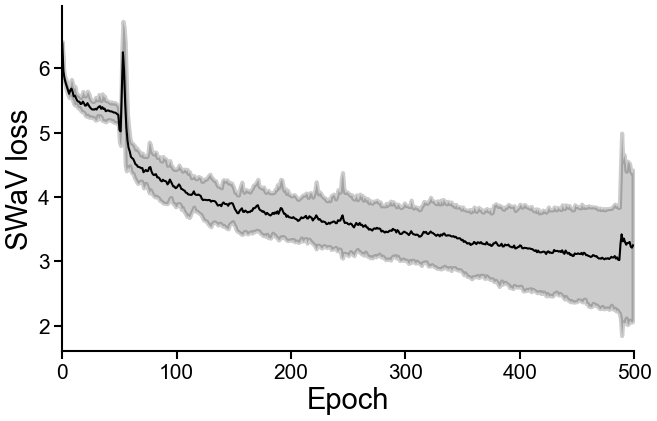

In [4]:
# # logs = pd.read_csv(logs_path)
# fig, ax = plt.subplots(1, 1, figsize=(60*MM_TO_IN, 40*MM_TO_IN))
# plot_kwargs = {
#     'x': 'epoch',
#     'y': 'train_loss_epoch',
#     'ax': ax,
#     'markeredgewidth': 0.5,
#     'linewidth': 0.5,
# }

# for i, logs_path in enumerate(logs_paths):
#     logs = pd.read_csv(logs_path["path"])
#     label = logs_path["label"]
#     color = logs_path["color"]
#     sns.lineplot(
#         data=logs,
#         label=label,
#         color=color,
#         **plot_kwargs
#         )
# ax.set_xlabel('Epoch'); ax.set_ylabel('SWaV loss')
# ax.set_xlim(0, logs['epoch'].max())

fig, ax = plt.subplots(1, 1, figsize=(60*MM_TO_IN, 40*MM_TO_IN))
mean_loss = all_logs.groupby("epoch").mean()
std_loss = all_logs.groupby("epoch").std()
ax.plot(mean_loss.index, mean_loss["train_loss_epoch"], color="k")
ax.fill_between(
    mean_loss.index,
    mean_loss["train_loss_epoch"] - std_loss["train_loss_epoch"],
    mean_loss["train_loss_epoch"] + std_loss["train_loss_epoch"],
    color="k", alpha=0.2)
ax.set_xlabel('Epoch'); ax.set_ylabel('SWaV loss')
ax.set_xlim(0, all_logs['epoch'].max())

ax.set_xticks(np.arange(0, 501, 100))

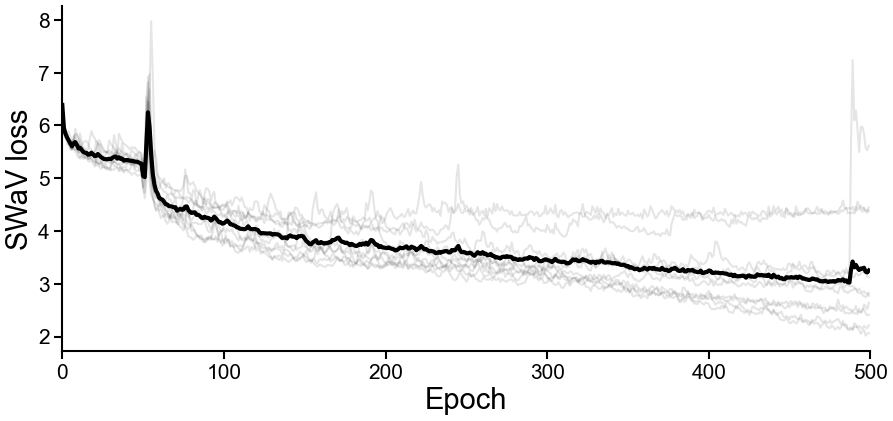

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(80*MM_TO_IN, 40*MM_TO_IN))
sns.lineplot(
    data=all_logs,
    x='epoch',
    y='train_loss_epoch',
    hue='seed',
    ax=ax,
    markeredgewidth=0.5,
    linewidth=0.5,
    alpha=0.1,
    hue_norm=(10, 10),
    palette='Greys_r'
)
ax.plot(mean_loss.index, mean_loss["train_loss_epoch"], color="k", lw=1)
# turn off legend
ax.get_legend().remove()
ax.set_xlabel('Epoch'); ax.set_ylabel('SWaV loss')
ax.set_xlim(0, all_logs['epoch'].max())

ax.set_xticks(np.arange(0, 501, 100))

fig.savefig(ospj(CONFIG.fig_dir, "swav_loss_across_seeds.pdf"), dpi=300, bbox_inches='tight')

## Apply final model

In [14]:
# get best model
best_model = all_logs.query('epoch == 499').sort_values('train_loss_epoch').iloc[0]

ckpt_path = ospj(
    "/mnt/leif/littlab/users/pattnaik/ieeg_sz_embedding/checkpoints",
    f"checkpoints_seed_{int(best_model['seed'])}",
    f"model_epoch-epoch={int(best_model['epoch'])}-train_loss={best_model['train_loss_epoch']:.5f}.ckpt"
)
assert os.path.exists(ckpt_path)

In [13]:
ckpt_path

'/mnt/leif/littlab/users/pattnaik/ieeg_sz_embedding/checkpoints/checkpoints_10s/model_epoch-epoch=499-train_loss=2.95853.ckpt'

In [15]:
model_nn = MultivarWav2Vec2(MODEL_CONFIG)
model = ModelV3WrapperWithQueue.load_from_checkpoint(ckpt_path, model=model_nn)
# get best model
model = model.model
model = model.eval()

dataset = SzDatasetRegsFull()
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

In [16]:
all_tokens = np.zeros((len(dataset), MODEL_CONFIG.prototype_dim))
all_regs = []
n_signals = np.zeros(len(dataset))
device = 'cpu'
all_eegs = []
all_ch_names = []

model = model.to(device)
model.eval()
for batch in tqdm(dataloader):
    # get the inputs
    signals, regs, ch_names, idx = batch
    regs = regs.long().to(device)
    # signals = [s.float().to(device) for s in signals]
    signals = signals.float().to(device)
    signals = signals[:, :, :int(256*10)]

    # forward pass
    output = model(signals, regs)

    all_tokens[idx] = output.detach().cpu().numpy()
    all_regs.append(regs.cpu().numpy())
    all_eegs.append(signals.cpu().numpy())
    all_ch_names.append([i[0] for i in ch_names])

    n_signals[idx] = np.sum(np.all((signals.cpu().numpy() == 0), axis=-1), axis=-1)
sz_embeddings = all_tokens[~np.any(np.isnan(all_tokens), axis=-1)]
n_signals = n_signals[~np.any(np.isnan(all_tokens), axis=-1)]
sz_metadata = dataset.metadata[~np.any(np.isnan(all_tokens), axis=-1)]
all_eegs = np.concatenate(all_eegs, axis=0)
all_regs = np.concatenate(all_regs, axis=0)
all_eegs = all_eegs[~np.any(np.isnan(all_tokens), axis=-1)]
all_regs = all_regs[~np.any(np.isnan(all_tokens), axis=-1)]

all_ch_names = [ch_names for i, ch_names in enumerate(all_ch_names) if not np.any(np.isnan(all_tokens), axis=-1)[i]]

metadata = sz_metadata.copy().reset_index(drop=True)

  0%|          | 0/888 [00:00<?, ?it/s]

In [17]:
unique_regs = pd.read_csv(regs_path)

In [9]:
# get cosine similarity
euclid_dist = euclidean_distances(sz_embeddings)
cosine_sim = cosine_similarity(sz_embeddings)

## Are patients with similar implantation marked as similar?

In [17]:
# compute jacard similarity
from scipy.spatial.distance import pdist
from scipy.spatial.distance import jaccard, squareform

jaccard_dist = pdist(all_regs, metric=jaccard)
jaccard_sim = 1 - squareform(jaccard_dist)

<Axes: >

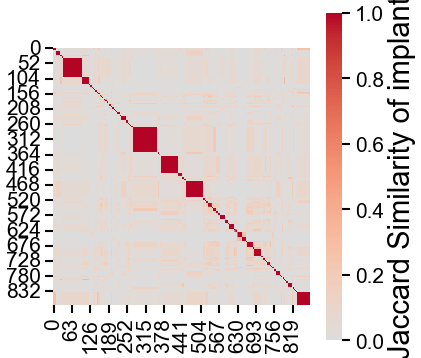

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))
sns.heatmap(
    jaccard_sim,
    cbar_kws={
        'label': 'Jaccard Similarity of implant', 
        # make it smaller
        'shrink': 0.8,
    },
    square=True,
    ax=ax,
    cmap='coolwarm',
    center=0
)

r_value: 0.04, p_value: 1.701e-101


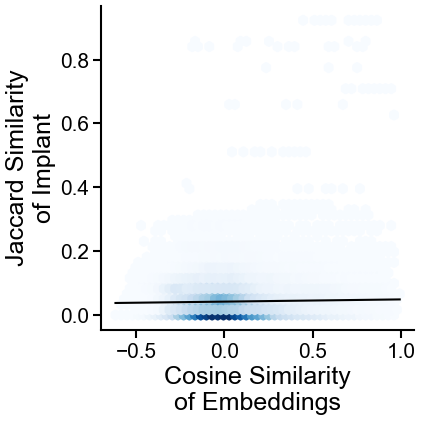

In [19]:
# scatter plot
x_vals = cosine_sim[np.triu_indices(cosine_sim.shape[0], k=1)]
y_vals = jaccard_sim[np.triu_indices(jaccard_sim.shape[0], k=1)]

x_vals = x_vals[y_vals != 1]
y_vals = y_vals[y_vals != 1]

fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))
# sns.scatterplot(
#     x=x_vals,
#     y=y_vals,
#     ax=ax,
#     alpha=0.5,
#     s=1
# )
ax.hexbin(
    x_vals,
    y_vals,
    gridsize=50,
    cmap='Blues',
    mincnt=1
    )
ax.set_xlabel('Cosine Similarity\nof Embeddings', fontsize=6)
ax.set_ylabel('Jaccard Similarity\nof Implant', fontsize=6)

# get slope, intercept and p values
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals)

# plot the line
x = np.linspace(
    np.min(x_vals),
    np.max(x_vals),
    100
)
y = slope * x + intercept
ax.plot(x, y, 'k', label=f'y = {slope:.2f}x + {intercept:.2f}')

print(f"r_value: {r_value:.2f}, p_value: {p_value:.3e}")

r_value: -0.19, p_value: 0.000e+00


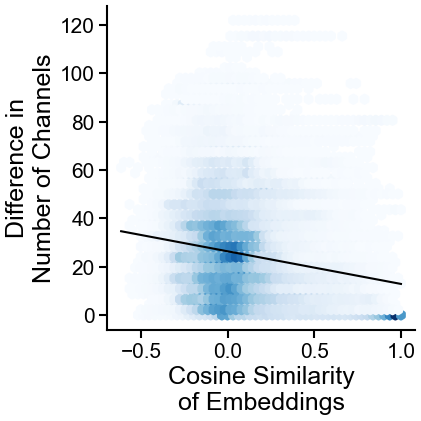

In [20]:
x_vals = cosine_sim[np.triu_indices(cosine_sim.shape[0], k=1)]

diff_channels = np.abs(n_signals - n_signals[:, None])
y_vals = diff_channels[np.triu_indices(diff_channels.shape[0], k=1)]

fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))
ax.hexbin(
    x_vals,
    y_vals,
    gridsize=50,
    cmap='Blues',
    mincnt=1
    )
ax.set_xlabel('Cosine Similarity\nof Embeddings', fontsize=6)
ax.set_ylabel('Difference in\nNumber of Channels', fontsize=6)

slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals)

# plot the line
x = np.linspace(
    np.min(x_vals),
    np.max(x_vals),
    100
)
y = slope * x + intercept
ax.plot(x, y, 'k', label=f'y = {slope:.2f}x + {intercept:.2f}')

print(f"r_value: {r_value:.2f}, p_value: {p_value:.3e}")



## Dimensionality reduction plot

In [67]:
reducer_name = 'Spectral'

if reducer_name == 'UMAP':
    reducer = umap.UMAP(random_state=42)
elif reducer_name == 'TSNE':
    reducer = TSNE(n_components=2, random_state=42)
elif reducer_name == 'PCA':
    reducer = PCA(n_components=2)
elif reducer_name == 'Spectral':
    reducer = SpectralEmbedding(n_components=2)

sz_embeddings_reduced = reducer.fit_transform(sz_embeddings)

if reducer_name == 'UMAP':
    reducer = umap.UMAP(random_state=42, n_components=3)
elif reducer_name == 'TSNE':
    reducer = TSNE(n_components=3, random_state=42)
elif reducer_name == 'PCA':
    reducer = PCA(n_components=3)
elif reducer_name == 'Spectral':
    reducer = SpectralEmbedding(n_components=3)
sz_embeddings_reduced3d = reducer.fit_transform(sz_embeddings)

[]

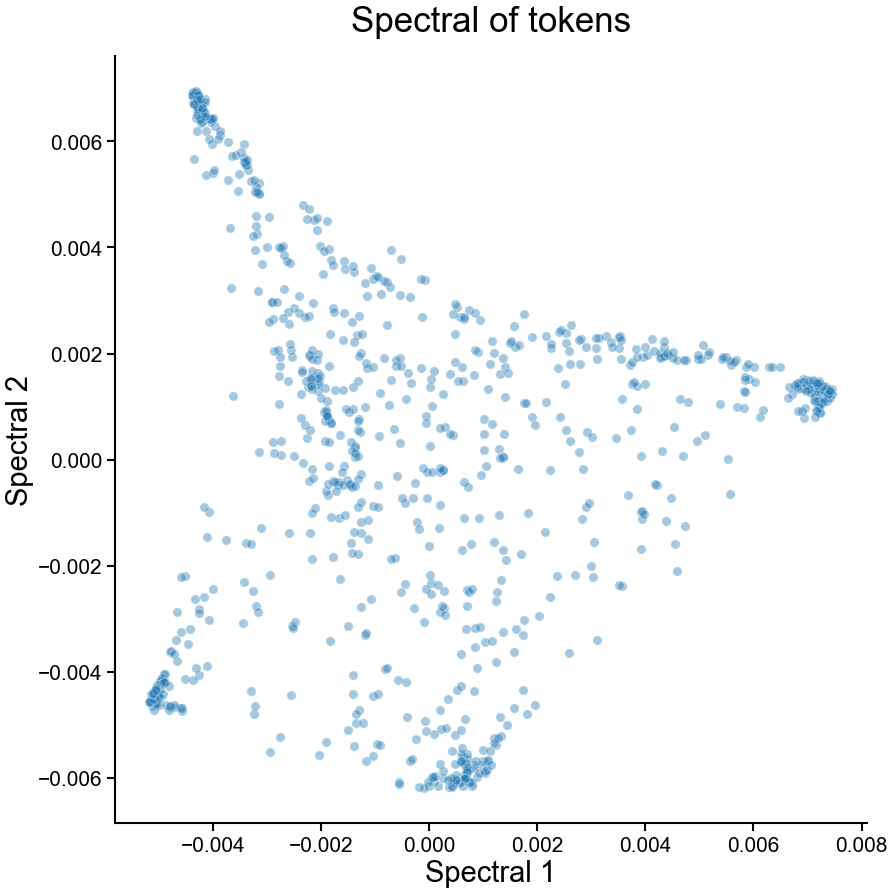

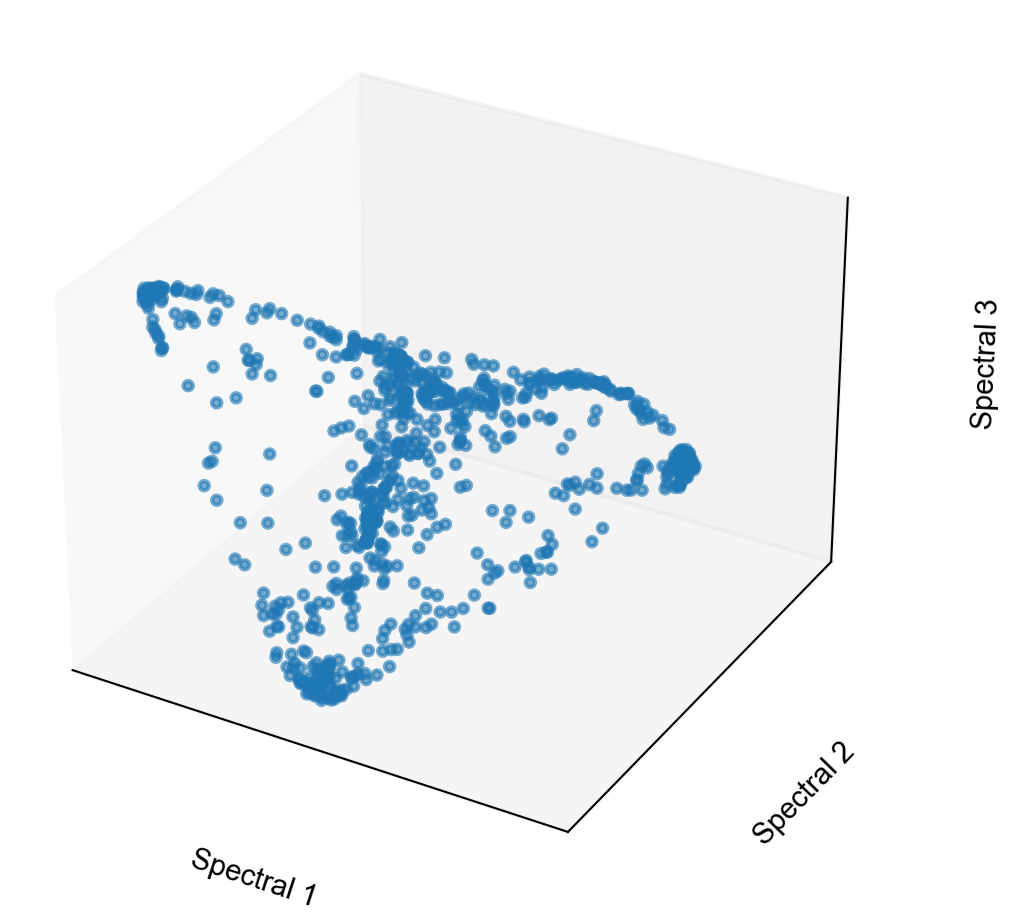

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(80*MM_TO_IN, 80*MM_TO_IN))
sns.scatterplot(
    x=sz_embeddings_reduced[:, 0],
    y=sz_embeddings_reduced[:, 1],
    alpha=0.4,
    s=5,
    ax=ax,
    legend=False)
ax.set_xlabel(f'{reducer_name} 1')
ax.set_ylabel(f'{reducer_name} 2')
ax.set_title(f'{reducer_name} of tokens')
sns.despine()

fig = plt.figure(figsize=(80*MM_TO_IN, 80*MM_TO_IN))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    sz_embeddings_reduced3d[:, 0],
    sz_embeddings_reduced3d[:, 1],
    sz_embeddings_reduced3d[:, 2],
    alpha=0.6,
    s=5,
    # hue=n_signals[~nan_mask],
)
ax.set_xlabel(f'{reducer_name} 1')
ax.set_ylabel(f'{reducer_name} 2')
ax.set_zlabel(f'{reducer_name} 3')

ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

In [25]:
# save 3d points
np.save(ospj(CONFIG.data_dir, "gui_data", f"sz_embeddings_reduced3d_{reducer_name}.npy"), sz_embeddings_reduced3d)

In [30]:
print(sz_embeddings_reduced3d.shape)

(878, 3)


## Clustering

In [31]:
print(np.isinf(sz_embedding_sim).sum())
print(np.isnan(sz_embedding_sim).sum())

NameError: name 'sz_embedding_sim' is not defined

In [32]:
from sklearn.metrics import silhouette_samples
from scipy.stats import sem

k = np.arange(2, 256, 2)
silhouettes = np.zeros_like(k, dtype=float)
silhouettes = np.zeros((len(k),len(sz_embeddings)))

for i, n in enumerate(k):
    # clusters = AgglomerativeClustering(n_clusters=n, metric='cosine', linkage='average').fit_predict(sz_embeddings)
    clusters = SpectralClustering(n_clusters=n, affinity='rbf', assign_labels='cluster_qr').fit_predict(sz_embeddings)

    silhouette_arr = silhouette_samples(sz_embeddings, clusters, metric='cosine')
    silhouettes[i] = silhouette_arr

best_k = k[np.argmax(np.mean(silhouettes, axis=-1))]
best_k = 36
mean_sil = np.mean(silhouettes, axis=-1)

slope_sil = np.diff(mean_sil)
slope_sil = np.concatenate([slope_sil, [0]])



In [33]:

# get max mean and slope point
best_k = np.mean(np.vstack((mean_sil, slope_sil)), axis=0)
best_k = np.argmax(best_k)
best_k = 55

# find first index where mean is above 0.5
best_k = np.argmax(mean_sil > 0.39)
# best_k = np.argmax(mean_sil)
best_k = k[best_k]

print(f"best_k: {best_k}")

# clusters = AgglomerativeClustering(n_clusters=best_k, metric='cosine', linkage='average').fit_predict(sz_embeddings)
clusters = SpectralClustering(n_clusters=best_k, affinity='rbf', assign_labels='cluster_qr').fit_predict(sz_embeddings)

# reassign cluster numbers based on frequency
cluster_counts = np.bincount(clusters)
cluster_map = np.argsort(np.argsort(cluster_counts))
clusters = cluster_map[clusters]

# np.save(ospj(save_dir, 'clusters.npy'), clusters)
# np.save(ospj(save_dir, 'silhouettes.npy'), silhouettes)

best_k: 22


In [36]:
clusters.shape

# save to gui_data
np.save(ospj(CONFIG.data_dir, "gui_data", f"clusters.npy"), clusters)

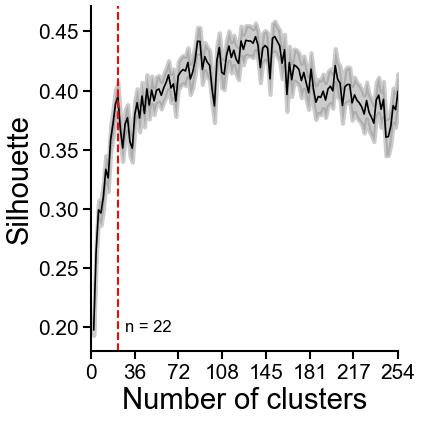

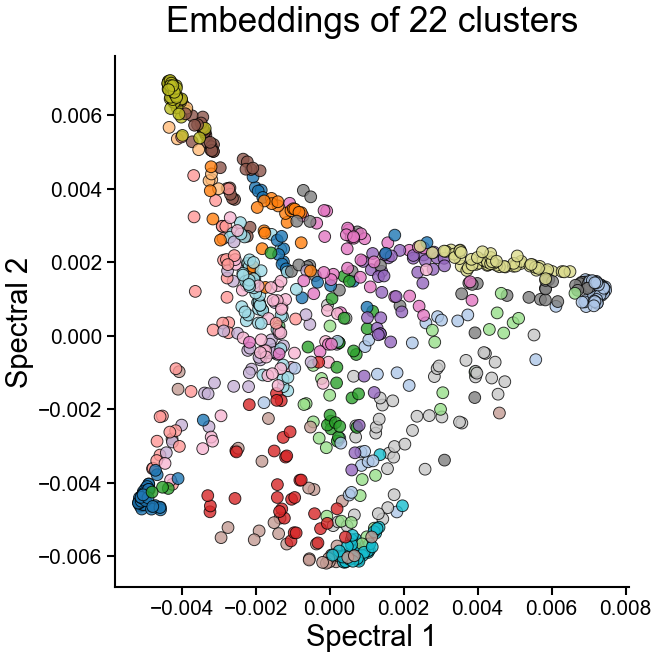

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))
# silhouette score with best k
sns.lineplot(
    x=k,
    y=np.mean(silhouettes, axis=-1),
    ax=ax,
    lw=0.4,
    color='k'
)
stds = np.std(silhouettes, axis=-1)
sems = sem(silhouettes, axis=-1)
ax.fill_between(k, np.mean(silhouettes, axis=-1) - sems, np.mean(silhouettes, axis=-1) + sems, alpha=0.4, color='tab:gray')

ax.axvline(best_k, color='r', linestyle='--')
ax.text(best_k + 25, 0.2, f'n = {best_k}', color='black', ha='center', va='center', fontdict={'size': 4})
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Silhouette')
# ax.set_title('Determining optimal k')
ax.set_xlim(0, np.max(k))
# ax.set_ylim(0, 1)
ax.set_xticks(np.linspace(0, np.max(k), 8, endpoint=True, dtype=int))

sns.despine(ax=ax)
# plt.tight_layout()
fig.savefig(ospj(CONFIG.fig_dir, 'silhouette_score.pdf'), transparent=True, dpi=300, bbox_inches='tight')

fig, ax = plt.subplots(1, 1, figsize=(60*MM_TO_IN, 60*MM_TO_IN))
sns.scatterplot(
    x=sz_embeddings_reduced[:, 0],
    y=sz_embeddings_reduced[:, 1],
    hue=clusters,
    ax=ax,
    palette='tab20',
    s=8,
    alpha=0.8,
    edgecolor='k',
    legend=False)
ax.set_title(f"Embeddings of {best_k} clusters")
ax.set_xlabel(f'{reducer_name} 1')
ax.set_ylabel(f'{reducer_name} 2')
sns.despine()
fig.savefig(ospj(CONFIG.fig_dir, 'clusters.pdf'), transparent=True, dpi=300, bbox_inches='tight')

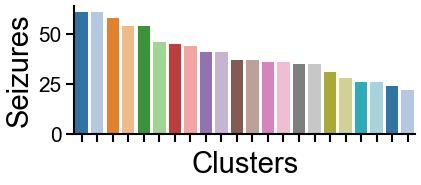

In [38]:
# barplot of number of seizures per cluster
cluster_counts = np.bincount(clusters)
cluster_counts = cluster_counts[cluster_counts != 0]
# sort
cluster_counts = np.sort(cluster_counts)[::-1]
fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 20*MM_TO_IN))
sns.barplot(
    x=np.arange(len(cluster_counts)),
    y=cluster_counts,
    ax=ax,
    palette='tab20'
)
ax.set_xticklabels([])
ax.set_xlabel("Clusters")
ax.set_ylabel("Seizures")

fig.savefig(ospj(CONFIG.fig_dir, 'cluster_counts.pdf'), transparent=True, dpi=300, bbox_inches='tight')

In [39]:
patient_to_clusters = dict()
clusters_to_patients = dict()

# make a contingency table of patient and cluster
contingency = pd.crosstab(sz_metadata['Patient'], clusters)
for ind, row in contingency.iterrows():
    # print(f"Patient {ind} has {row.sum()} samples across {len(row[row > 0])} clusters")
    patient_to_clusters[ind] = {"seizures": row.sum(), "clusters": len(row[row > 0])}

for i in range(best_k):
    # print(f"Cluster {i} has {contingency[i].sum()} samples from {len(contingency[contingency[i] > 0])} patients")
    clusters_to_patients[i] = {"seizures": contingency[i].sum(), "patients": len(contingency[contingency[i] > 0])}

patient_to_clusters = pd.DataFrame(patient_to_clusters).T.sort_values('clusters', ascending=False)
clusters_to_patients = pd.DataFrame(clusters_to_patients).T.sort_values('patients', ascending=False)

display(patient_to_clusters.query('clusters > 3'))
display(clusters_to_patients.query('patients > 1'))

,seizures,clusters
sub-RID0582,20,5
sub-RID0033,43,5
sub-RID0131,10,5
sub-RID0272,5,4
sub-RID0649,12,4
sub-RID0329,83,4


,seizures,patients
19,58,16
14,44,15
13,41,13
15,45,13
7,35,11
11,37,10
5,31,10
6,35,10
9,36,9
10,37,9


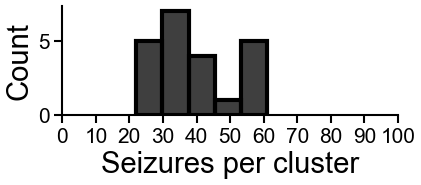

In [40]:
# make histograms of seizures per cluster
fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 20*MM_TO_IN))
sns.histplot(
    data=clusters_to_patients,
    x='seizures',
    ax=ax,
    bins=5,
    # discrete=True,
    color='k'
)
# make ticks be integers
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
ax.set_xticks(np.arange(0, 110, 10))
ax.set_xlabel('Seizures per cluster')
ax.set_ylabel('Count')

fig.savefig(ospj(CONFIG.fig_dir, 'seizures_per_cluster.pdf'), transparent=True, dpi=300, bbox_inches='tight')


Median seizures per cluster: 37.0
IQR seizures per cluster: 13.75
Median patients per cluster: 7.5
IQR patients per cluster: 5.75


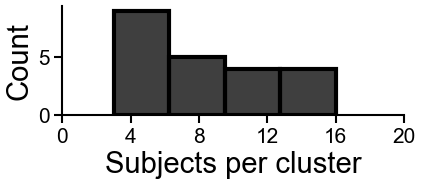

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 20*MM_TO_IN))
sns.histplot(
    data=clusters_to_patients,
    x='patients',
    ax=ax,
    bins=4,
    # discrete=True,
    color='k'
)
# make ticks be integers
ax.set_xticks(np.arange(0, 22, 4))
# ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
ax.set_xlabel('Subjects per cluster')
ax.set_ylabel('Count')

fig.savefig(ospj(CONFIG.fig_dir, 'patients_per_cluster.pdf'), transparent=True, dpi=300, bbox_inches='tight')

# print median and iqr
print(f"Median seizures per cluster: {np.median(cluster_counts)}")
print(f"IQR seizures per cluster: {np.diff(np.percentile(cluster_counts, [25, 75]))[0]}")

# print median and iqr
print(f"Median patients per cluster: {np.median(clusters_to_patients['patients'])}")
print(f"IQR patients per cluster: {np.diff(np.percentile(clusters_to_patients['patients'], [25, 75]))[0]}")



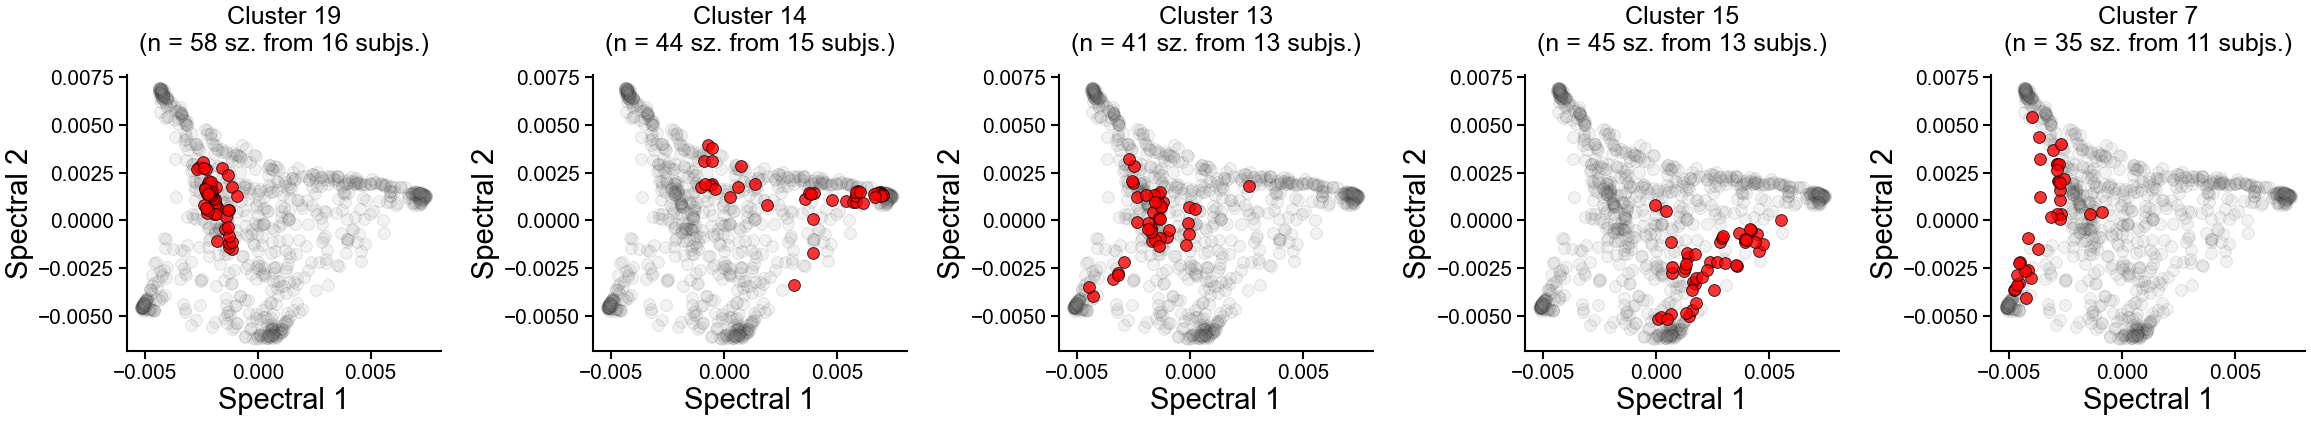

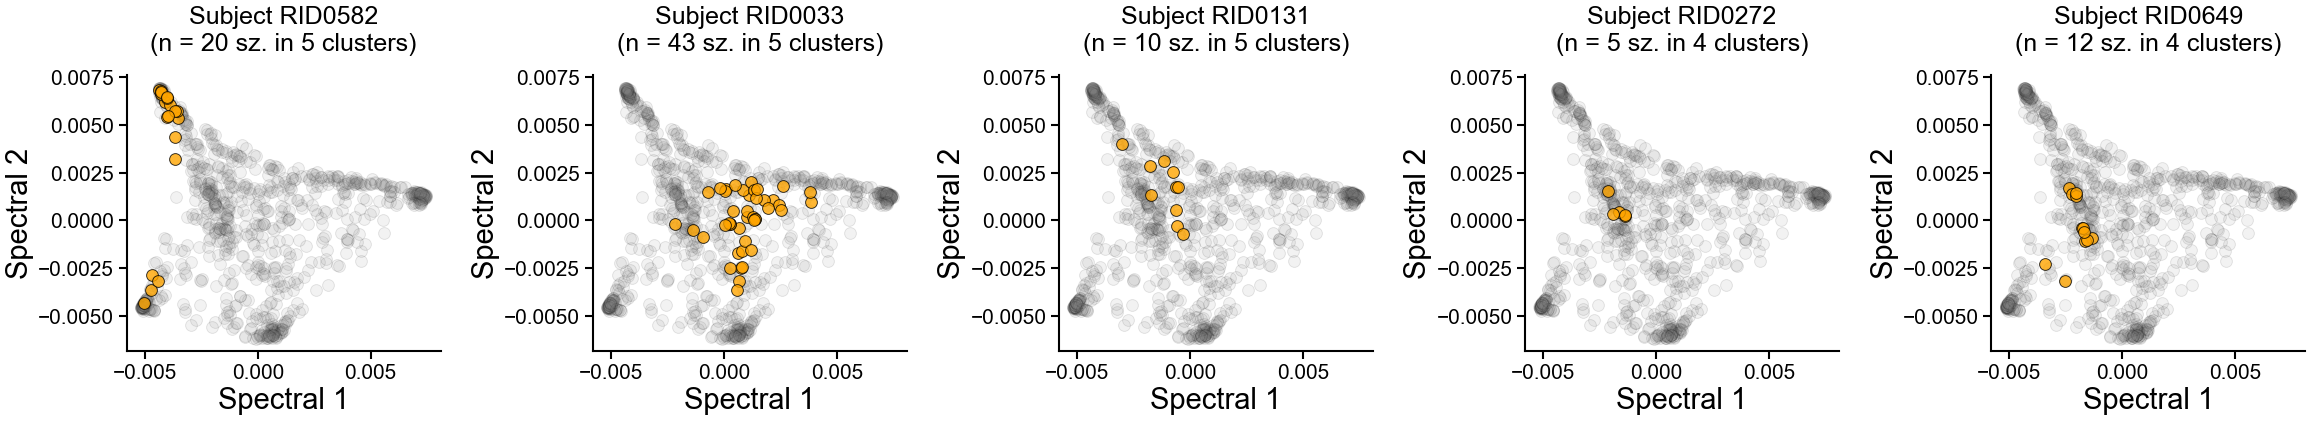

In [214]:
plot_kwargs = {
    "s": 8,
    "edgecolor": 'k',
    "legend": False
}
N_EXAMPLES = 5

selected_clusters = clusters_to_patients.query('patients > 1').index[:N_EXAMPLES]
selected_patients = patient_to_clusters.query('clusters > 1').index[:N_EXAMPLES]

fig, axes = plt.subplots(1, len(selected_clusters), figsize=(40*MM_TO_IN*N_EXAMPLES, 40*MM_TO_IN))

for clust, ax in zip(selected_clusters, axes.flat):
    # display(contingency[contingency[clust] > 0][clust].to_frame())
    sns.scatterplot(
        x=sz_embeddings_reduced[clusters != clust, 0],
        y=sz_embeddings_reduced[clusters != clust, 1],
        color='grey',
        alpha=0.1,
        ax=ax,
        **plot_kwargs,
        )
    sns.scatterplot(
        x=sz_embeddings_reduced[clusters == clust, 0],
        y=sz_embeddings_reduced[clusters == clust, 1],
        color='r',
        alpha=0.8,
        ax=ax,
        **plot_kwargs,
        )
    title = f"Cluster {clust}\n(n = {clusters_to_patients.loc[clust, 'seizures']} sz. from {clusters_to_patients.loc[clust, 'patients']} subjs.)"
    ax.set_title(title, fontsize=6)
    ax.set_xlabel(f'{reducer_name} 1')
    ax.set_ylabel(f'{reducer_name} 2')
    sns.despine()

fig, axes = plt.subplots(1, len(selected_clusters), figsize=(40*MM_TO_IN*N_EXAMPLES, 40*MM_TO_IN))

for pat, ax in zip(selected_patients, axes.flat):
    # display(contingency.loc[pat][contingency.loc[pat] > 0].to_frame())
    sns.scatterplot(
        x=sz_embeddings_reduced[sz_metadata['Patient'] != pat, 0],
        y=sz_embeddings_reduced[sz_metadata['Patient'] != pat, 1],
        color='grey',
        alpha=0.1,
        ax=ax,
        **plot_kwargs,
        )
    sns.scatterplot(
        x=sz_embeddings_reduced[sz_metadata['Patient'] == pat, 0],
        y=sz_embeddings_reduced[sz_metadata['Patient'] == pat, 1],
        color='orange',
        alpha=0.8,
        ax=ax,
        **plot_kwargs,
        )
    title = f"Subject {pat.replace('sub-', '')}\n(n = {patient_to_clusters.loc[pat, 'seizures']} sz. in {patient_to_clusters.loc[pat, 'clusters']} clusters)"
    ax.set_title(title, fontsize=6)
    ax.set_xlabel(f'{reducer_name} 1')
    ax.set_ylabel(f'{reducer_name} 2')
    sns.despine()

## Patient level analysis

In [24]:
pt_avg_dist = dict()
metadata = sz_metadata.copy().reset_index(drop=True)

for pt, group in metadata.groupby('Patient'):
    embeddings = sz_embeddings[group.index]
    if len(embeddings) == 1:
        continue
    # compute average pairwise cosine similarity
    cos_sim = cosine_similarity(embeddings)
    cos_sim = cos_sim[np.triu_indices_from(cos_sim, k=1)]
    avg_cos_sim = np.mean(cos_sim)
    pt_avg_dist[pt] = avg_cos_sim

pt_avg_dist = pd.DataFrame(pt_avg_dist, index=['avg_cosine_similarity']).T
pt_avg_dist = pt_avg_dist.sort_values('avg_cosine_similarity', ascending=True)

least_clust_pts = pt_avg_dist.index[:N_EXAMPLES]
most_clust_pts = pt_avg_dist.index[-N_EXAMPLES:]
most_clust_pts = most_clust_pts[::-1]

In [25]:
display(pt_avg_dist.loc[least_clust_pts])
display(pt_avg_dist.loc[most_clust_pts])

,avg_cosine_similarity
sub-RID0459,0.211241
sub-RID0502,0.430521


,avg_cosine_similarity
sub-RID0589,0.999837
sub-RID0566,0.999474


NameError: name 'sz_embeddings_reduced' is not defined

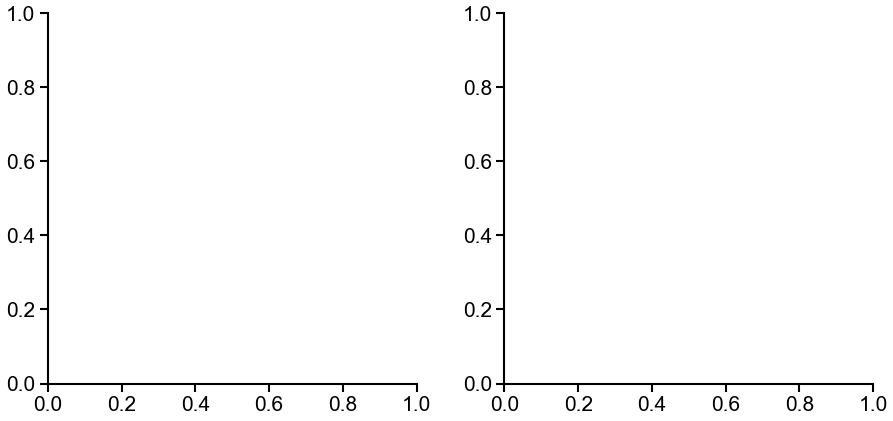

In [26]:
N_EXAMPLES = 2

fig, axes = plt.subplots(1, N_EXAMPLES, figsize=(40*MM_TO_IN*N_EXAMPLES, 40*MM_TO_IN))

for pat, ax in zip(least_clust_pts, axes.flat):
    # display(contingency.loc[pat][contingency.loc[pat] > 0].to_frame())
    sns.scatterplot(
        x=sz_embeddings_reduced[sz_metadata['Patient'] != pat, 0],
        y=sz_embeddings_reduced[sz_metadata['Patient'] != pat, 1],
        color='grey',
        alpha=0.1,
        ax=ax,
        **plot_kwargs,
        )
    sns.scatterplot(
        x=sz_embeddings_reduced[sz_metadata['Patient'] == pat, 0],
        y=sz_embeddings_reduced[sz_metadata['Patient'] == pat, 1],
        color='orange',
        alpha=0.8,
        ax=ax,
        **plot_kwargs,
        )
    title = f"Subject {pat.replace('sub-', '')}\n(n = {patient_to_clusters.loc[pat, 'seizures']} sz. in {patient_to_clusters.loc[pat, 'clusters']} clusters)\naverage similarity: {pt_avg_dist.loc[pat, 'avg_cosine_similarity']:.3f}"
    ax.set_title(title, fontsize=5)
    ax.set_xlabel(f'{reducer_name} 1')
    ax.set_ylabel(f'{reducer_name} 2')
    sns.despine()

fig, axes = plt.subplots(1, N_EXAMPLES, figsize=(40*MM_TO_IN*N_EXAMPLES, 40*MM_TO_IN))

for pat, ax in zip(most_clust_pts, axes.flat):
    # display(contingency.loc[pat][contingency.loc[pat] > 0].to_frame())
    sns.scatterplot(
        x=sz_embeddings_reduced[sz_metadata['Patient'] != pat, 0],
        y=sz_embeddings_reduced[sz_metadata['Patient'] != pat, 1],
        color='grey',
        alpha=0.1,
        ax=ax,
        **plot_kwargs,
        )
    sns.scatterplot(
        x=sz_embeddings_reduced[sz_metadata['Patient'] == pat, 0],
        y=sz_embeddings_reduced[sz_metadata['Patient'] == pat, 1],
        color='orange',
        alpha=0.8,
        ax=ax,
        **plot_kwargs,
        )
    title = f"Subject {pat.replace('sub-', '')}\n(n = {patient_to_clusters.loc[pat, 'seizures']} sz. in {patient_to_clusters.loc[pat, 'clusters']} clusters)\naverage similarity: {pt_avg_dist.loc[pat, 'avg_cosine_similarity']:.3f}"
    ax.set_title(title, fontsize=5)
    ax.set_xlabel(f'{reducer_name} 1')
    ax.set_ylabel(f'{reducer_name} 2')
    sns.despine()

NameError: name 'sz_embeddings_reduced' is not defined

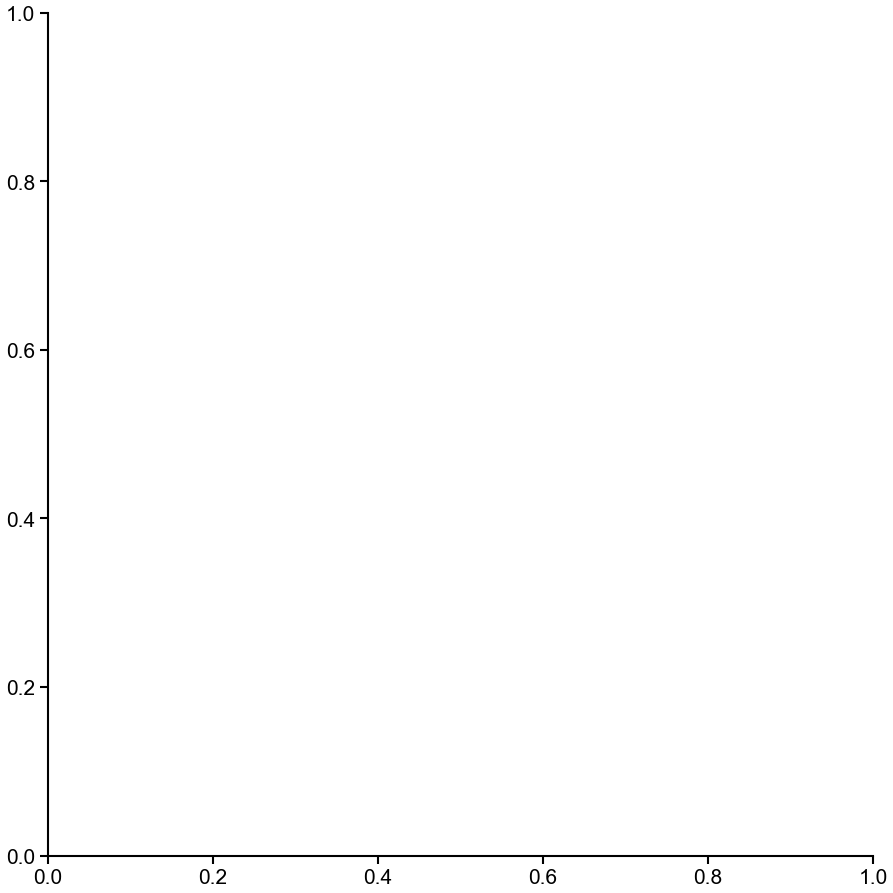

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(80*MM_TO_IN, 80*MM_TO_IN))

least_most_clust = ['sub-RID0307', 'sub-RID0381']
cols = ['tab:green', 'tab:orange']

sns.scatterplot(
    x=sz_embeddings_reduced[~sz_metadata['Patient'].isin(least_most_clust), 0],
    y=sz_embeddings_reduced[~sz_metadata['Patient'].isin(least_most_clust), 1],
    color='grey',
    alpha=0.1,
    ax=ax,
    s=15,
    edgecolor='k',
    legend=False
    )

for pat, col in zip(least_most_clust, cols):
    sns.scatterplot(
        x=sz_embeddings_reduced[sz_metadata['Patient'] == pat, 0],
        y=sz_embeddings_reduced[sz_metadata['Patient'] == pat, 1],
        color=col,
        alpha=0.8,
        ax=ax,
        s=15,
        edgecolor='k',
        legend=False
        )
    ax.set_xlabel(f'{reducer_name} 1')
    ax.set_ylabel(f'{reducer_name} 2')
    ax.set_xticks([]); ax.set_yticks([])
    sns.despine()

fig.savefig(ospj(CONFIG.fig_dir, 'least_most_clusters.pdf'), transparent=True, dpi=300, bbox_inches='tight')

In [ ]:
# example patient
pt = "sub-RID0307"

metadata.rename(columns={'index': 'seizure_id'}, inplace=True)
assert len(metadata) - 1 == metadata.index[-1]

# get seizure ids and cluster indices
seizure_ids = metadata.query(f'Patient == "{pt}"')


pt_clusters = clusters[metadata.query(f'Patient == "{pt}"').index]

# pick a random seizure from each cluster
unique_clusters = np.unique(pt_clusters)

for clust in unique_clusters:
    sz_id = seizure_ids[pt_clusters == clust].sample(1, random_state=2).index[0]
    display(metadata.loc[sz_id])
    fig = eeg_plotter(sz_id)
    fig.savefig(ospj(CONFIG.fig_dir, f'{pt}_cluster_{np.where(unique_clusters == clust)[0][0]}.pdf'), transparent=True, dpi=300, bbox_inches='tight')
    print(f"fname = {pt}_cluster_{np.where(unique_clusters == clust)[0][0]}.pdf")


pt = "sub-RID0381"
seizure_ids = metadata.query(f'Patient == "{pt}"')
pt_clusters = clusters[metadata.query(f'Patient == "{pt}"').index]

for sz_id in seizure_ids.index:
    fig = eeg_plotter(sz_id)
    fig.savefig(ospj(CONFIG.fig_dir, f'{pt}_cluster_{np.where(seizure_ids.index == sz_id)[0][0]}.pdf'), transparent=True, dpi=300, bbox_inches='tight')



NameError: name 'metadata' is not defined

In [12]:
pt_embeddings = metadata.groupby('Patient').apply(lambda x: np.sum(sz_embeddings[x.index], axis=0) / np.linalg.norm(np.sum(sz_embeddings[x.index], axis=0)))
pt_names = pt_embeddings.index
pt_embeddings = np.vstack(pt_embeddings)

# apply hierarchical clustering
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# compute pairwise cosine similarity
cos_sim = cosine_similarity(pt_embeddings)

# compute linkage
Z = linkage(pdist(pt_embeddings, metric='cosine'), method='average')

new_pt_order = dendrogram(Z, labels=pt_names, orientation='right', no_plot=True)['ivl']
new_pt_order_idx = [np.where(pt_names == pt)[0][0] for pt in new_pt_order]

fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))
sns.heatmap(
    cos_sim[new_pt_order_idx][:, new_pt_order_idx],
    ax=ax,
    cmap='coolwarm',
    cbar=True,
    center=0,
    cbar_kws={
        'label': 'Cosine Similarity', 
        'shrink': 0.6,
    },
)
ax.set_aspect('equal', adjustable='box')
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel('Subject')
ax.set_ylabel('Subject')

reducer_name = "Spectral"
if reducer_name == 'UMAP':
    reducer = umap.UMAP(random_state=42)
elif reducer_name == 'TSNE':
    reducer = TSNE(n_components=2, random_state=42)
elif reducer_name == 'PCA':
    reducer = PCA(n_components=2)
elif reducer_name == 'Spectral':
    reducer = SpectralEmbedding(n_components=2)

pt_embeddings_reduced = reducer.fit_transform(pt_embeddings)

fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))
sns.scatterplot(
    x=pt_embeddings_reduced[:, 0],
    y=pt_embeddings_reduced[:, 1],
    alpha=0.6,
    s=8,
    ax=ax,
    legend=False)

ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel(f'{reducer_name} 1')
ax.set_ylabel(f'{reducer_name} 2')
ax.set_title(f'{reducer_name} of tokens')
sns.despine()


NameError: name 'metadata' is not defined

## Positional Embedding

,reg,reg_idx
0,Amyg_Hipp_L,1
1,ParaHippocampal_L,2
2,thalam_limbic_L,3
3,Insula_L,4
4,Temporal_Inf_L,5
5,Temporal_Mid_L,6
6,Temporal_Sup_L,7
7,Frontal_Mid_All_L,8
8,Frontal_Sup_All_L,9
9,Frontal_inf_All_L,10


[(8, 'Frontal_Mid_All_L'), (6, 'Temporal_Mid_L'), (7, 'Temporal_Sup_L'), (10, 'Frontal_inf_All_L'), (5, 'Temporal_Inf_L'), (1, 'Amyg_Hipp_L'), (25, 'Temporal_Inf_R'), (13, 'SupraMarginal_Angular_L'), (11, 'Precentral_L'), (28, 'Frontal_Mid_All_R'), (9, 'Frontal_Sup_All_L'), (30, 'Frontal_inf_All_R'), (29, 'Frontal_Sup_All_R'), (26, 'Temporal_Mid_R'), (19, 'Parietal_Sup_Inf_L'), (31, 'Precentral_R'), (12, 'Postcentral_L'), (21, 'Amyg_Hipp_R'), (16, 'Fusiform_L'), (36, 'Fusiform_R'), (27, 'Temporal_Sup_R'), (4, 'Insula_L'), (22, 'ParaHippocampal_R'), (39, 'Parietal_Sup_Inf_R'), (14, 'Cingulum_L'), (3, 'thalam_limbic_L'), (33, 'SupraMarginal_Angular_R'), (2, 'ParaHippocampal_L'), (34, 'Cingulum_R'), (17, 'Occipital_Lat_L'), (32, 'Postcentral_R'), (23, 'thalam_limbic_R'), (24, 'Insula_R'), (37, 'Occipital_Lat_R'), (20, 'Precuneus_PCL_L'), (18, 'Occipital_Med_L'), (40, 'Precuneus_PCL_R'), (15, 'FMO_Rect_L'), (38, 'Occipital_Med_R'), (35, 'FMO_Rect_R')]


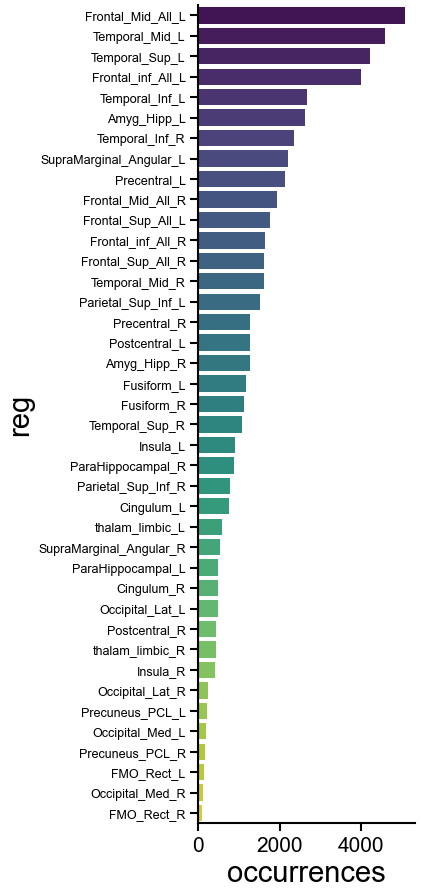

In [29]:
regs = pd.read_csv(regs_path)
regs['reg_idx'] = regs.index + 1

display(regs)

all_regs_li = all_regs
all_regs_li = rearrange(all_regs_li, 'b n -> (b n)')
all_regs_occurrences = pd.DataFrame(all_regs_li).value_counts().to_frame('occurrences')
all_regs_occurrences.index = all_regs_occurrences.index.map(lambda x: x[0])
all_regs_occurrences = all_regs_occurrences.drop(0)
all_regs_occurrences['reg'] = all_regs_occurrences.index.map(lambda x: regs.loc[x - 1, 'reg'])

fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 80*MM_TO_IN))
sns.barplot(
    x='occurrences',
    y='reg',
    data=all_regs_occurrences,
    ax=ax,
    palette='viridis',
)
# make y tick labels smaller
ax.set_yticklabels(ax.get_yticklabels(), fontsize=3)

min_regs = 2
# min_regs = 1
ax.axvline(min_regs, color='r', linestyle='--')

selected_reg_names = all_regs_occurrences[all_regs_occurrences['occurrences'] >= min_regs]['reg'].values
selected_reg_idx = all_regs_occurrences[all_regs_occurrences['occurrences'] >= min_regs].index
print(list(zip(selected_reg_idx, selected_reg_names)))

In [30]:
pos_embed = model.spatiotemporal_pos_encoder.pos_embedding.detach().cpu().numpy()
print(pos_embed.shape)
pos_embed_selected = pos_embed[regs['reg_idx'].values]

print(pos_embed_selected.shape)

(41, 20, 32)
(40, 20, 32)


PermissionError: [Errno 13] Permission denied: '/mnt/leif/littlab/users/pattnaik/ieeg_sz_embedding/figures/pos_embed_frames_corr.pdf'

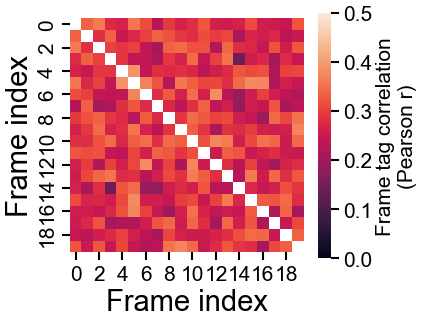

In [31]:
# check correlation of frames
pos_embed_frames = rearrange(pos_embed_selected, 'r f d -> f (r d)')
pos_embed_frames_corr = np.corrcoef(pos_embed_frames)
# set diagonal to nan
np.fill_diagonal(pos_embed_frames_corr, np.nan)
fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))
sns.heatmap(
    pos_embed_frames_corr,
    cbar_kws={
        'shrink': 0.6,
    },
    square=True,
    ax=ax,
    vmin=0,
    vmax=0.5,
)
ax.set_xlabel('Frame index'); ax.set_ylabel('Frame index')
# make cbar title smaller
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel('Frame tag correlation\n(Pearson r)', fontsize=5)
# save
fig.savefig(ospj(CONFIG.fig_dir, "pos_embed_frames_corr.pdf"), dpi=300, bbox_inches='tight')

Correlation: -0.358, p-value: 0.000


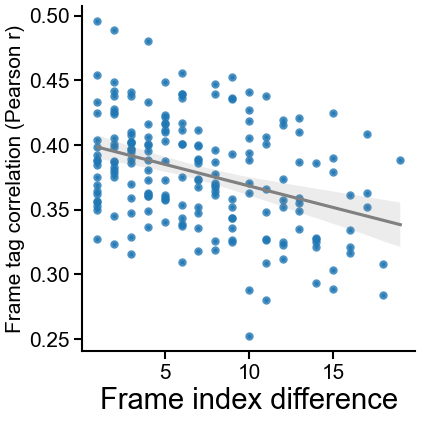

In [ ]:
# make a scatter plot where each point has x value (difference in frame number) and y value (correlation)
pair_corrs = pos_embed_frames_corr[np.triu_indices_from(pos_embed_frames_corr, k=1)]
frame_diffs = np.abs(np.subtract(*np.meshgrid(np.arange(pos_embed_frames_corr.shape[0]), np.arange(pos_embed_frames_corr.shape[0]))))
frame_diffs = frame_diffs[np.triu_indices_from(frame_diffs, k=1)]

mask = frame_diffs < 100
pair_corrs = pair_corrs[mask]
frame_diffs = frame_diffs[mask]

# fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))
# make lmplot
x_col_name = 'Frame index difference'
# y_col_name = 'Pos. enc. tag correlation'
y_col_name = 'Frame tag correlation (Pearson r)'
data = pd.DataFrame({
    x_col_name: frame_diffs,
    y_col_name: pair_corrs
})

corr_plot = sns.lmplot(
    x=x_col_name,
    y=y_col_name,
    data=data,
    scatter_kws={'s': 1},
    height=40*MM_TO_IN,
    aspect=1,
    line_kws={'color': 'grey'}
)
# make ylabel smaller
corr_plot.set_ylabels(fontsize=5)

# get correlation and p value
from scipy.stats import pearsonr
corr, p_val = pearsonr(frame_diffs, pair_corrs)
print(f"Correlation: {corr:.3f}, p-value: {p_val:.3f}")

# save
# fig.savefig(ospj(CONFIG.fig_dir, "pos_embed_frames_corr_scatter.pdf"), dpi=300, bbox_inches='tight')
# save
corr_plot.savefig(ospj(CONFIG.fig_dir, "pos_embed_frames_corr_scatter.pdf"), dpi=300, bbox_inches='tight')

In [ ]:
all_regs

array([[2, 5, 5, ..., 0, 0, 0],
       [2, 5, 5, ..., 0, 0, 0],
       [2, 5, 5, ..., 0, 0, 0],
       ...,
       [5, 5, 5, ..., 0, 0, 0],
       [5, 5, 5, ..., 0, 0, 0],
       [5, 5, 5, ..., 0, 0, 0]])

[Text(0, 0.5, 'Amyg_Hipp_L'),
 Text(0, 1.5, 'ParaHippocampal_L'),
 Text(0, 2.5, 'thalam_limbic_L'),
 Text(0, 3.5, 'Insula_L'),
 Text(0, 4.5, 'Temporal_Inf_L'),
 Text(0, 5.5, 'Temporal_Mid_L'),
 Text(0, 6.5, 'Temporal_Sup_L'),
 Text(0, 7.5, 'Frontal_Mid_All_L'),
 Text(0, 8.5, 'Frontal_Sup_All_L'),
 Text(0, 9.5, 'Frontal_inf_All_L'),
 Text(0, 10.5, 'Precentral_L'),
 Text(0, 11.5, 'Postcentral_L'),
 Text(0, 12.5, 'SupraMarginal_Angular_L'),
 Text(0, 13.5, 'Cingulum_L'),
 Text(0, 14.5, 'FMO_Rect_L'),
 Text(0, 15.5, 'Fusiform_L'),
 Text(0, 16.5, 'Occipital_Lat_L'),
 Text(0, 17.5, 'Occipital_Med_L'),
 Text(0, 18.5, 'Parietal_Sup_Inf_L'),
 Text(0, 19.5, 'Precuneus_PCL_L'),
 Text(0, 20.5, 'Amyg_Hipp_R'),
 Text(0, 21.5, 'ParaHippocampal_R'),
 Text(0, 22.5, 'thalam_limbic_R'),
 Text(0, 23.5, 'Insula_R'),
 Text(0, 24.5, 'Temporal_Inf_R'),
 Text(0, 25.5, 'Temporal_Mid_R'),
 Text(0, 26.5, 'Temporal_Sup_R'),
 Text(0, 27.5, 'Frontal_Mid_All_R'),
 Text(0, 28.5, 'Frontal_Sup_All_R'),
 Text(0, 29.5, 'Fr

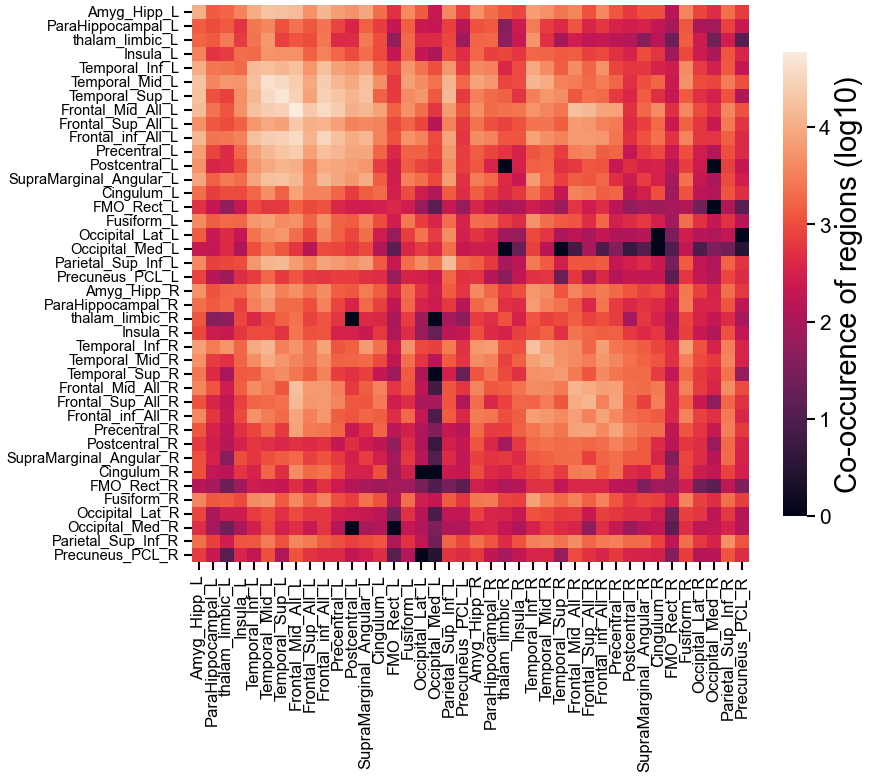

In [32]:
# get a count of the number of times a pair of regions are present in the same seizure
reg_pair_occurrences = np.zeros((len(np.unique(all_regs)), len(np.unique(all_regs))))

for sz_regs in all_regs:
    for i, j in itertools.combinations(sz_regs, 2):
        if (i == 0) or (j == 0):
            continue
        reg_pair_occurrences[i, j] += 1
        reg_pair_occurrences[j, i] += 1

# remove first row and column
reg_pair_occurrences = reg_pair_occurrences[1:, 1:]

fig, ax = plt.subplots(1, 1, figsize=(80*MM_TO_IN, 80*MM_TO_IN))
sns.heatmap(
    np.log10(reg_pair_occurrences + 1),
    square=True,
    # cmap='Reds',
    cbar_kws={
        'label': 'Co-occurence of regions (log10)', 
        'shrink': 0.6,
    },
    ax=ax
)
ax.set_xticks(np.arange(reg_pair_occurrences.shape[0]) + 0.5); ax.set_yticks(np.arange(reg_pair_occurrences.shape[0]) + 0.5)
ax.set_xticklabels(regs.reg, rotation=90, fontdict={'size': 4}); ax.set_yticklabels(regs.reg, rotation=0, fontdict={'size': 3.5})

50th percentile: 914.0


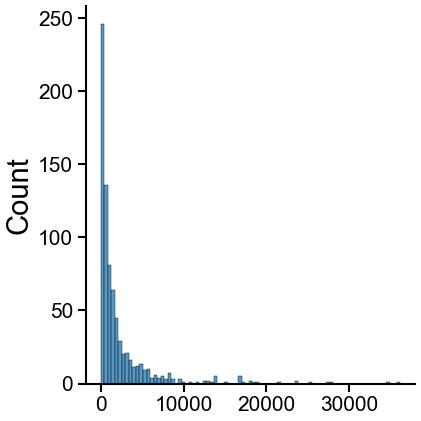

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))

sns.histplot(
    reg_pair_occurrences[np.triu_indices_from(reg_pair_occurrences, k=1)],
    ax=ax,
)

print(f"50th percentile: {np.percentile(reg_pair_occurrences, 50)}")

[Text(0, 0.5, '0'),
 Text(0, 1.5, '1'),
 Text(0, 2.5, '2'),
 Text(0, 3.5, '3'),
 Text(0, 4.5, '4'),
 Text(0, 5.5, '5'),
 Text(0, 6.5, '6'),
 Text(0, 7.5, '7'),
 Text(0, 8.5, '8'),
 Text(0, 9.5, '9'),
 Text(0, 10.5, '10'),
 Text(0, 11.5, '11'),
 Text(0, 12.5, '12'),
 Text(0, 13.5, '13'),
 Text(0, 14.5, '14'),
 Text(0, 15.5, '15'),
 Text(0, 16.5, '16'),
 Text(0, 17.5, '17'),
 Text(0, 18.5, '18'),
 Text(0, 19.5, '19'),
 Text(0, 20.5, '20'),
 Text(0, 21.5, '21'),
 Text(0, 22.5, '22'),
 Text(0, 23.5, '23'),
 Text(0, 24.5, '24'),
 Text(0, 25.5, '25'),
 Text(0, 26.5, '26'),
 Text(0, 27.5, '27'),
 Text(0, 28.5, '28'),
 Text(0, 29.5, '29'),
 Text(0, 30.5, '30'),
 Text(0, 31.5, '31'),
 Text(0, 32.5, '32'),
 Text(0, 33.5, '33'),
 Text(0, 34.5, '34'),
 Text(0, 35.5, '35'),
 Text(0, 36.5, '36'),
 Text(0, 37.5, '37'),
 Text(0, 38.5, '38'),
 Text(0, 39.5, '39')]

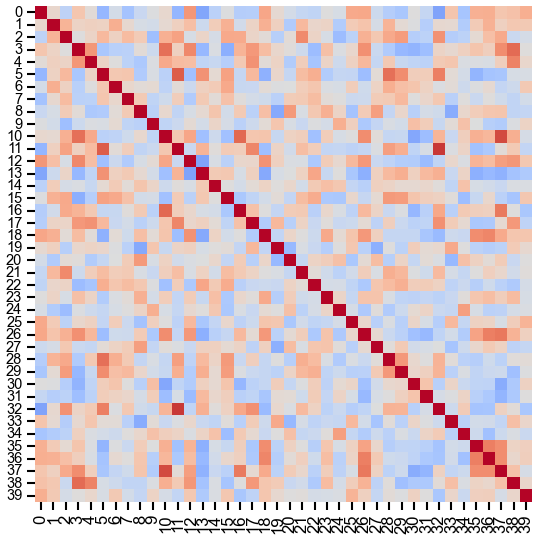

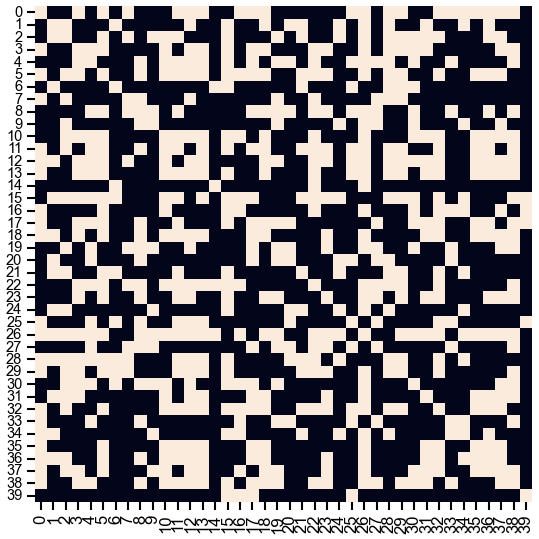

In [34]:
# compute pearson correlation for each frame
reg_corr_frames = []
for i_f in range(pos_embed_selected.shape[1]):
    reg_corr_frames.append(np.corrcoef(pos_embed_selected[:, i_f]))

reg_corr_frames = np.array(reg_corr_frames)

fig, ax = plt.subplots(1, 1, figsize=(50*MM_TO_IN, 50*MM_TO_IN))
sns.heatmap(
    reg_corr_frames.mean(axis=0),
    ax=ax,
    cbar=False,
    cmap='coolwarm',
    center=0
)
ax.set_xticks(np.arange(reg_corr_frames.shape[1]) + 0.5); ax.set_yticks(np.arange(reg_corr_frames.shape[1]) + 0.5)
ax.set_xticklabels(np.arange(reg_corr_frames.shape[1]), rotation=90, fontdict={'size': 4}); ax.set_yticklabels(np.arange(reg_corr_frames.shape[1]), rotation=0, fontdict={'size': 3.5})

# only keep ones where the sign is stable in 80% of the frames
stable_sign = np.abs(np.sum(np.sign(reg_corr_frames), axis=0)) >= (0.9 * reg_corr_frames.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(50*MM_TO_IN, 50*MM_TO_IN))
sns.heatmap(
    stable_sign,
    ax=ax,
    cbar=False,
)
ax.set_xticks(np.arange(reg_corr_frames.shape[1]) + 0.5); ax.set_yticks(np.arange(reg_corr_frames.shape[1]) + 0.5)
ax.set_xticklabels(np.arange(reg_corr_frames.shape[1]), rotation=90, fontdict={'size': 4}); ax.set_yticklabels(np.arange(reg_corr_frames.shape[1]), rotation=0, fontdict={'size': 3.5})


(40, 40)


PermissionError: [Errno 13] Permission denied: '/mnt/leif/littlab/users/pattnaik/ieeg_sz_embedding/figures/pos_embed_regs_corr.pdf'

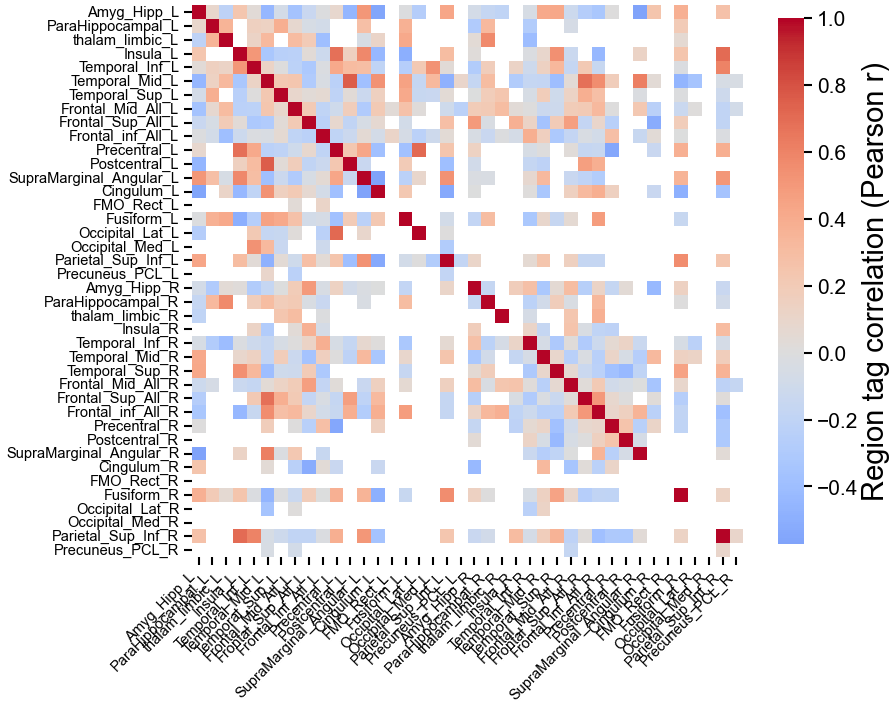

In [35]:
# sort_idx = np.argsort(selected_reg_names)
# pos_embed_selected = pos_embed_selected[sort_idx]
# selected_reg_names = selected_reg_names[sort_idx]

pos_embed_regs = rearrange(pos_embed_selected, 'r f d -> r (f d)')
pos_embed_regs_corr = np.corrcoef(pos_embed_regs)

pos_embed_regs_corr = reg_corr_frames.mean(axis=0)

# pos_embed_regs_corr = np.abs(pos_embed_regs_corr)
print(pos_embed_regs_corr.shape)


# filter by occurrences
pos_embed_regs_corr[reg_pair_occurrences < 914] = np.nan
# pos_embed_regs_corr[stable_sign == False] = np.nan


fig, ax = plt.subplots(1, 1, figsize=(80*MM_TO_IN, 80*MM_TO_IN))
sns.heatmap(
    pos_embed_regs_corr,
    cbar_kws={
        'label': 'Region tag correlation (Pearson r)', 
        'shrink': 0.6,
    },
    square=True,
    ax=ax,
    cmap='coolwarm',
    center=0
)
ax.set_xticks(np.arange(pos_embed_regs.shape[0]) + 0.5); ax.set_yticks(np.arange(pos_embed_regs.shape[0]) + 0.5)
ax.set_xticklabels(regs.reg.values, rotation=45, fontdict={'size': 3.5}, ha='right'); ax.set_yticklabels(regs.reg.values, rotation=0, fontdict={'size': 3.5})
# save
fig.savefig(ospj(CONFIG.fig_dir, "pos_embed_regs_corr.pdf"), dpi=300, bbox_inches='tight')

## Clinical variables

### Assemble clinical variables

In [10]:
cols_to_keep = ['record_id', 'sex',
       'epilepsy_onset_yr', 'age_iEEGimplant','seizure_Engel12m', 'seizure_Engel24m','MRI_lesion','ieeg_isFocal', 'therapy']

manual_metadata = pd.read_excel(manual_metadata_path)
manual_metadata = manual_metadata.query('rid in @sz_metadata.Patient')

master_metadata = pd.read_excel(master_metadata_path)
master_metadata['record_id'] = master_metadata['record_id'].apply(lambda x: "sub-RID" + str(x).zfill(4))
master_metadata = master_metadata.query('record_id in @sz_metadata.Patient')
master_metadata = master_metadata[cols_to_keep]

master_metadata = master_metadata.rename(columns={'record_id': 'rid'})

master_metadata = master_metadata.merge(manual_metadata, on='rid', how='left')

master_metadata.loc[master_metadata.therapy_y.isin(['RNS', 'VNS', 'DBS', 'DBS (explanted)']), 'therapy_y'] = 'Neuromodulatory device'


master_metadata.loc[master_metadata.target == 'Bihippocampal', 'target'] = 'Bilateral'
master_metadata.loc[master_metadata.target == 'Bitemporal', 'target'] = 'Bilateral'
master_metadata.loc[master_metadata.target == 'Insula', 'target'] = 'Insular'
master_metadata.loc[master_metadata.target == 'MTL', 'target'] = 'Temporal'
master_metadata.loc[master_metadata.target == 'MFL', 'target'] = 'Frontal'
master_metadata.loc[master_metadata.target == 'Cingulate', 'target'] = 'Other'
master_metadata.loc[master_metadata.target == 'Neocortical', 'target'] = 'Other'
master_metadata.loc[master_metadata.target == 'Parietal', 'target'] = 'Other'
master_metadata.loc[master_metadata.target == 'SMA', 'target'] = 'Other'
master_metadata.loc[master_metadata.target == '?', 'target'] = 'Unknown'
master_metadata.loc[master_metadata.target == 'TP', 'target'] = 'Temporal'
master_metadata.loc[master_metadata.target == 'FP', 'target'] = 'Frontal'

master_metadata.loc[master_metadata.laterality == '?', 'laterality'] = np.nan

master_metadata.loc[pd.isna(master_metadata.implant), 'implant'] = "Unknown"
master_metadata.loc[pd.isna(master_metadata.therapy_y), 'therapy_y'] = "Unknown"


master_metadata.loc[master_metadata['MRI lesional'] == '?', 'MRI lesional'] = np.nan
# Non-Lesional (PET Hypometabolism)
master_metadata.loc[master_metadata['MRI lesional'] == 'Non-Lesional (PET Hypometabolism) ', 'MRI lesional'] = "Non-Lesional"

# fill where "MRI lesional" is nan based on "MRI_lesion"
master_metadata.loc[pd.isna(master_metadata["MRI lesional"]), "MRI lesional"] = master_metadata.loc[pd.isna(master_metadata["MRI lesional"]), "MRI_lesion"].map({"Y": "Lesional", "N": "Non-Lesional"})

# convert age_iEEGimplant to ranges for every decade
master_metadata['age'] = master_metadata['age_iEEGimplant'].apply(lambda x: f"{int(x//10)*10}-{int(x//10)*10+9}")

final_fields = ["rid", "therapy_y", "implant", "sex", "target", "laterality", "MRI lesional", "age", "seizure_Engel12m", "seizure_Engel24m", "ieeg_isFocal"]
master_metadata = master_metadata[final_fields]
master_metadata = master_metadata.rename(columns={
    "therapy_y": "therapy",
    "MRI lesional": "mri_lesion",
    "seizure_Engel12m": "engel_12",
    "seizure_Engel24m": "engel_24",
})


# good outcome
master_metadata['outcome'] = ""

for ind, row in master_metadata.iterrows():
    if (row['engel_12'] < 2) and (pd.isna(row['engel_24'])):
        master_metadata.loc[ind, 'outcome'] = "good"
        continue
    if (row['engel_12'] >= 2) and (pd.isna(row['engel_24'])):
        master_metadata.loc[ind, 'outcome'] = "poor"
        continue
    if (pd.isna(row['engel_12'])) and pd.isna(row['engel_24']):
        continue
    if (row['engel_12'] < 2) and (row['engel_24'] < 2):
        master_metadata.loc[ind, 'outcome'] = "good"
        continue
    if (row['engel_12'] < 2) and (row['engel_24'] >= 2):
        master_metadata.loc[ind, 'outcome'] = "poor"
        continue
    if (row['engel_12'] >= 2) and (row['engel_24'] < 2):
        master_metadata.loc[ind, 'outcome'] = "poor"
        continue
    if (row['engel_12'] >= 2) and (row['engel_24'] >= 2):
        master_metadata.loc[ind, 'outcome'] = "poor"
        continue


# join master metadata with sz_metadata
master_metadata = master_metadata.merge(sz_metadata, left_on='rid', right_on='Patient', how='right')

display(master_metadata)


,rid,therapy,implant,sex,target,laterality,mri_lesion,age,engel_12,engel_24,...,outcome,index,Patient,IEEGID,IEEGname,start,end,source,notes,Semiology
0,sub-RID0106,No surgery,ECoG,Female,No surgery,L,Non-Lesional,40-49,NaN,NaN,...,,0,sub-RID0106,1.0,HUP100_phaseII_D01,8816.7500,8911.44,Erin Excel,looked for seizure-y annotations and portal ti...,NaN
1,sub-RID0106,No surgery,ECoG,Female,No surgery,L,Non-Lesional,40-49,NaN,NaN,...,,1,sub-RID0106,1.0,HUP100_phaseII_D01,54591.2000,54637.74,Erin Excel,looked for seizure-y annotations and portal ti...,NaN
2,sub-RID0106,No surgery,ECoG,Female,No surgery,L,Non-Lesional,40-49,NaN,NaN,...,,2,sub-RID0106,1.0,HUP100_phaseII_D01,59253.0000,59312.60,Erin Excel,looked for seizure-y annotations and portal ti...,NaN
3,sub-RID0106,No surgery,ECoG,Female,No surgery,L,Non-Lesional,40-49,NaN,NaN,...,,3,sub-RID0106,1.0,HUP100_phaseII_D01,122854.4700,123127.10,Erin Excel,looked for seizure-y annotations and portal ti...,NaN
4,sub-RID0106,No surgery,ECoG,Female,No surgery,L,Non-Lesional,40-49,NaN,NaN,...,,4,sub-RID0106,1.0,HUP100_phaseII_D01,150988.6800,151059.30,Erin Excel,looked for seizure-y annotations and portal ti...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873,sub-RID0033,Resection,ECoG,Female,Temporal,L,Non-Lesional,30-39,1.1,1.1,...,good,1454,sub-RID0033,1.0,HUP097_phaseII,379495.2900,379675.29,annotations,looked for seizurey annotations and confirmed,NaN
874,sub-RID0033,Resection,ECoG,Female,Temporal,L,Non-Lesional,30-39,1.1,1.1,...,good,1455,sub-RID0033,1.0,HUP097_phaseII,383743.4800,383803.48,annotations,looked for seizurey annotations and confirmed,NaN
875,sub-RID0033,Resection,ECoG,Female,Temporal,L,Non-Lesional,30-39,1.1,1.1,...,good,1456,sub-RID0033,1.0,HUP097_phaseII,447452.3217,447767.32,annotations,looked for seizurey annotations and confirmed,NaN
876,sub-RID0033,Resection,ECoG,Female,Temporal,L,Non-Lesional,30-39,1.1,1.1,...,good,1457,sub-RID0033,1.0,HUP097_phaseII,476575.0400,476620.04,annotations,looked for seizurey annotations and confirmed,NaN


In [45]:
# save to gui_data
master_metadata.to_csv(ospj(CONFIG.data_dir, "gui_data", "master_metadata.csv"), index=False)

In [11]:
pt_level_metadata = master_metadata.drop_duplicates('rid')
# reorder to pt_names
pt_level_metadata = pt_level_metadata.set_index('rid').loc[pt_names]

from scipy.stats import chi2_contingency
categories = ['therapy', 'implant', 'target', 'laterality', 'mri_lesion', 'outcome']

demo_table = None
keys = []

for category in categories:
    if demo_table is None:
        demo_table = pd.crosstab(
            pt_level_metadata[category],
            pt_level_metadata['outcome'])
        
        demo_table.index = pd.MultiIndex.from_tuples(
            [(category, i) for i in demo_table.index]
        )
    
    else:
        temp = pd.crosstab(
            pt_level_metadata[category],
            pt_level_metadata['outcome']
        )
        
        temp.index = pd.MultiIndex.from_tuples(
            [(category, i) for i in temp.index]
        )
        
        demo_table = pd.concat([demo_table, temp], axis=0, sort=False)
    

demo_table.columns.name = None
n_good = (pt_level_metadata['outcome'] == 'good').sum()
n_poor =  (pt_level_metadata['outcome'] == 'poor').sum()

good_outcome_col_name = f"Engel 1 @ 2yrs (n = {n_good})"
poor_outcome_col_name = f"Engel 2+ @ 2yrs (n = {n_poor})"
# rename columns from False and True to Poor outcome and Good outcome, reorder so it's Good outcome, Poor outcome
demo_table = demo_table.rename(columns={"poor": poor_outcome_col_name, "good": good_outcome_col_name})[
    [good_outcome_col_name, poor_outcome_col_name]
]

# apply statistical tests to each category
for category in categories:
    table = pd.crosstab(
        pt_level_metadata[category],
        pt_level_metadata["outcome"]
    )
    
    _, p, _, _ = chi2_contingency(table)
    if p < 0.05:
        p = "p < 0.05"
    else:
        p = f"n.s."
    demo_table.loc[(category, "Chi-squared test")] = p

display(demo_table)

NameError: name 'pt_names' is not defined

In [37]:
assert sz_metadata.Patient.nunique() == pt_level_metadata.index.nunique(), f"Number of patients in sz_metadata {sz_metadata.Patient.nunique()} does not match number of patients in pt_level_metadata {pt_level_metadata.index.nunique()}"

print(pt_level_metadata.columns)

# columns to keep
cols_to_keep = ['therapy', 'implant', 'sex', 'target', 'mri_lesion', 'age', 'engel_12', 'engel_24', 'ieeg_isFocal']

final_table = pt_level_metadata[cols_to_keep].copy()
final_table = final_table.rename(columns={
    'therapy': 'Therapy',
    'implant': 'Implant',
    'sex': 'Sex',
    'target': 'Target',
    'mri_lesion': 'MRI Lesion',
    'age': 'Age at implant',
    'engel_12': 'Engel @ 12m',
    'engel_24': 'Engel @ 24m',
    'ieeg_isFocal': 'Focal iEEG'
})

display(final_table)

Index(['therapy', 'implant', 'sex', 'target', 'laterality', 'mri_lesion',
       'age', 'engel_12', 'engel_24', 'ieeg_isFocal', 'outcome', 'index',
       'Patient', 'IEEGID', 'IEEGname', 'start', 'end', 'source', 'notes',
       'Semiology'],
      dtype='object')


,Therapy,Implant,Sex,Target,MRI Lesion,Age at implant,Engel @ 12m,Engel @ 24m,Focal iEEG
Patient,,,,,,,,,
sub-RID0013,Resection,ECoG,Female,Temporal,Lesional,50-59,1.2,1.1,1.0
sub-RID0014,Resection,ECoG,Male,Other,Lesional,30-39,1.1,1.1,1.0
sub-RID0015,Neuromodulatory device,SEEG,Male,Bilateral,Lesional,50-59,3.1,3.1,1.0
sub-RID0020,Resection,ECoG,Male,Frontal,Lesional,20-29,1.1,1.4,1.0
sub-RID0021,Resection,ECoG,Female,Temporal,Lesional,30-39,1.4,1.4,1.0
...,...,...,...,...,...,...,...,...,...
sub-RID0648,Ablation,SEEG,Male,Temporal,Non-Lesional,20-29,4.1,4.1,0.0
sub-RID0649,No surgery,SEEG,Male,Frontal,Lesional,20-29,NaN,NaN,0.0
sub-RID0658,Ablation,SEEG,Female,Insular,Non-Lesional,20-29,1.1,NaN,1.0


In [38]:
cols_to_plot = ['therapy', 'implant', 'target', 'laterality', 'mri_lesion', 'outcome']
n_cols = len(cols_to_plot)

pt_level_metadata = master_metadata.drop_duplicates('rid')
# reorder to pt_names
pt_level_metadata = pt_level_metadata.set_index('rid').loc[pt_names]

In [39]:
from sklearn.metrics import silhouette_score

def bootstrap_clusters_old(clin_var, category, mask, n_bootstraps=100):
    n_cat = (pt_level_metadata[clin_var] == category).sum()

    null_dists = np.zeros(n_bootstraps)
    for i_bootstrap in range(n_bootstraps):
        # pick n_cat random patients
        patients = np.random.choice(np.arange(len(pt_level_metadata[mask])), size=n_cat, replace=False)
        # get the average distance from centroid for these patients
        sample_embeddings = pt_embeddings[mask][patients]
        sample_centroid = sample_embeddings.mean(axis=0)
        sample_dist = (sample_embeddings - sample_centroid)
        sample_dist = np.linalg.norm(sample_dist, axis=1)
        null_dists[i_bootstrap] = sample_dist.mean()

    # get the actual average distance from centroid for the category
    true_embeddings = pt_embeddings[pt_level_metadata[clin_var] == category]
    true_centroid = true_embeddings.mean(axis=0)
    true_dist = (true_embeddings - true_centroid)
    true_dist = np.linalg.norm(true_dist, axis=1)
    actual_avg_dist = true_dist.mean()

    p_val = (null_dists < actual_avg_dist).sum() / n_bootstraps

    return actual_avg_dist, p_val

def bootstrap_clusters(clin_var, mask, n_bootstraps=100, seed=42):
    # set seed
    np.random.seed(seed)
    true_partition = pt_level_metadata[mask][clin_var].values

    true_score = silhouette_score(pt_embeddings[mask], true_partition, metric='cosine')
    # compute within cluster sum of squares

    null_scores = np.zeros(n_bootstraps)
    for i_bootstrap in range(n_bootstraps):
        # pick a random partition
        random_partition = np.random.permutation(true_partition)
        null_scores[i_bootstrap] = silhouette_score(pt_embeddings[mask], random_partition, metric='cosine')
    
    p_val = (null_scores > true_score).sum() / n_bootstraps

    return p_val

therapy: 0.839
implant: 0.002
target: 0.499
laterality: 0.952
mri_lesion: 0.280
outcome: 0.179


/scratch/zcxu/miniconda3/envs/DL_compare/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


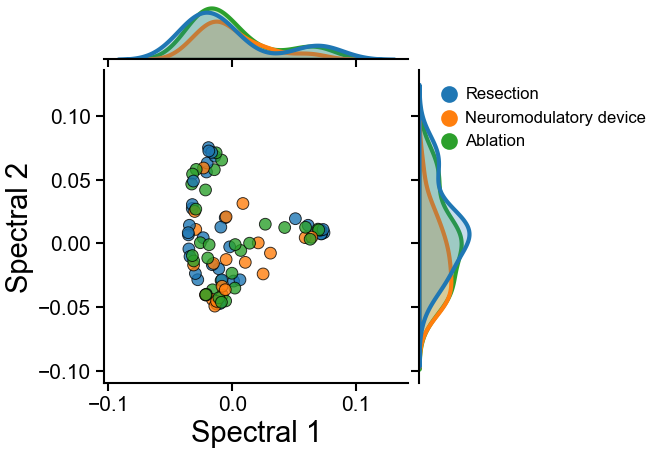

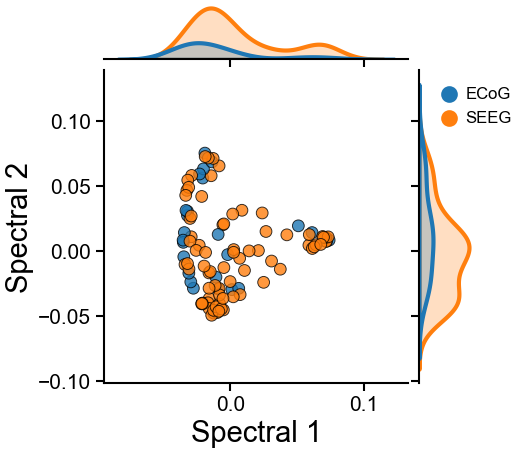

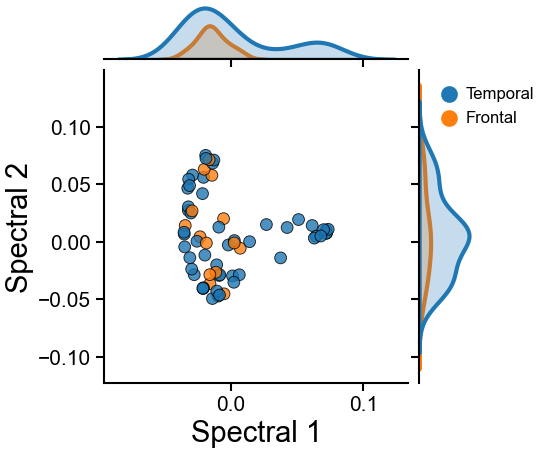

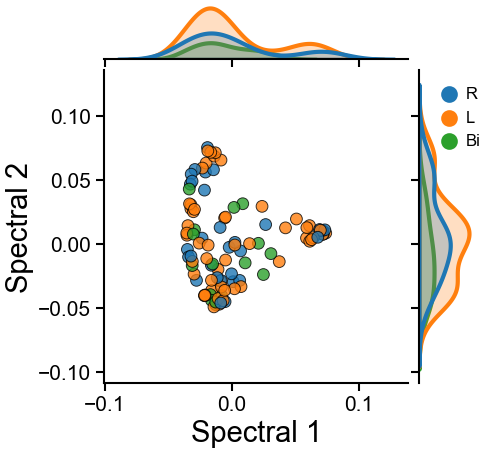

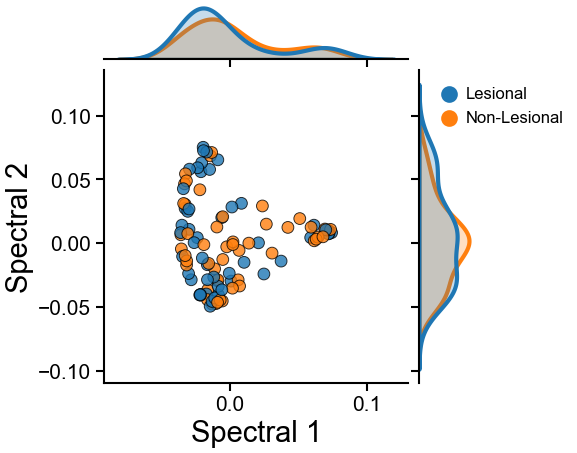

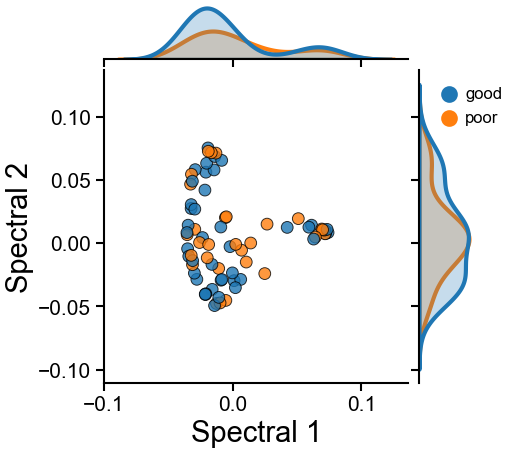

In [40]:
for col in cols_to_plot:
    if col == 'target':
        # only look at "Temporal" and "Frontal"
        mask = pt_level_metadata[col].isin(['Temporal', 'Frontal'])
    elif col == 'therapy':
        # only look at "Resective" and "Neuromodulatory device"
        mask = pt_level_metadata[col].isin(['Resection', 'Neuromodulatory device', 'Ablation'])
    elif col == 'outcome':
        mask = pt_level_metadata[col].isin(['good', 'poor'])
    else:
        mask = np.ones(len(pt_level_metadata), dtype=bool)
    
    jplt = sns.jointplot(
        x=pt_embeddings_reduced[mask, 0],
        y=pt_embeddings_reduced[mask, 1],
        hue=pt_level_metadata[col][mask],
        ax=ax,
        palette='tab10',
        s=8,
        alpha=0.8,
        edgecolor='k',
        height=40*MM_TO_IN,
    )
    jplt.ax_joint.set_xlabel(f'{reducer_name} 1')
    jplt.ax_joint.set_ylabel(f'{reducer_name} 2')

    # get the average distance from centroid for each category
    p_val = bootstrap_clusters(col, mask, n_bootstraps=1000)
    print(f"{col}: {p_val:.3f}")

    # move legend outside
    handles, labels = jplt.ax_joint.get_legend_handles_labels()
    jplt.ax_joint.legend(handles=handles, labels=labels, fontsize=4, markerscale=0.5, loc='upper left', bbox_to_anchor=(1.05, 1))

Text(0, 0.5, 'Adj. Rand index')

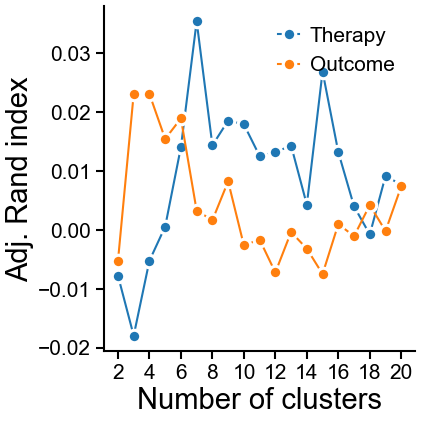

In [44]:
# for therapy and outcome, compute the rand index over different levels of hierarchical clustering. The end result should be a line plot with the rand index on the y-axis and the number of clusters on the x-axis

from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import AgglomerativeClustering

n_clusters = np.arange(2, 21)

therapy_rand = np.zeros(len(n_clusters))
outcome_rand = np.zeros(len(n_clusters))

therapy_mask = pt_level_metadata['therapy'].isin(['Resection', 'Neuromodulatory device', 'Ablation'])
outcome_mask = pt_level_metadata['outcome'].isin(['good', 'poor'])

# get the therapy labels
therapy_labels = pt_level_metadata['therapy'].values
outcome_labels = pt_level_metadata['outcome'].values

for i, n_clust in enumerate(n_clusters):
    # apply hierarchical clustering
    hc = AgglomerativeClustering(n_clusters=n_clust, metric='cosine', linkage='average')
    hc_labels = hc.fit_predict(pt_embeddings[therapy_mask])

    # apply spectral clustering
    sc = SpectralClustering(n_clusters=n_clust, affinity='nearest_neighbors', n_neighbors=10)
    sc_labels = sc.fit_predict(pt_embeddings[therapy_mask])

    therapy_rand[i] = adjusted_rand_score(therapy_labels[therapy_mask], sc_labels)

    sc_labels = sc.fit_predict(pt_embeddings[outcome_mask])
    outcome_rand[i] = adjusted_rand_score(outcome_labels[outcome_mask], sc_labels)

fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))
sns.lineplot(
    x=n_clusters,
    y=therapy_rand,
    ax=ax,
    label='Therapy',
    marker='o',
    markersize=3
)
sns.lineplot(
    x=n_clusters,
    y=outcome_rand,
    ax=ax,
    label='Outcome',
    marker='o',
    markersize=3,
)
ax.set_xlabel('Number of clusters')
ax.set_xticks(n_clusters[::2])
ax.set_ylabel('Adj. Rand index')

# save
# fig.savefig(ospj(CONFIG.fig_dir, "rand_index.pdf"), dpi=300, bbox_inches='tight', transparent=True)


Outcome Rand index: 0.023
(2, 4)


PermissionError: [Errno 13] Permission denied: '/mnt/leif/littlab/users/pattnaik/ieeg_sz_embedding/figures/outcome_clust_overlap.pdf'

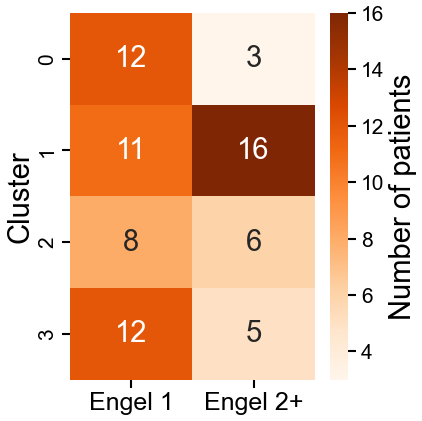

In [45]:
# plot cluster overlap heatmap for oouutcome and clustering at n = 7
hc = AgglomerativeClustering(n_clusters=7, metric='cosine', linkage='average')
sc = SpectralClustering(n_clusters=4, affinity='nearest_neighbors', n_neighbors=10)

sc_labels = sc.fit_predict(pt_embeddings[outcome_mask])
outcome_rand = adjusted_rand_score(outcome_labels[outcome_mask], sc_labels)

print(f"Outcome Rand index: {outcome_rand:.3f}")

outcome_clust_matrix = np.zeros((len(np.unique(outcome_labels[outcome_mask])), len(np.unique(sc_labels))))
print(outcome_clust_matrix.shape)

outcome_labels_mapper = list(np.unique(outcome_labels[outcome_mask]))
outcome_labels_clust = np.array([outcome_labels_mapper.index(i) for i in outcome_labels[outcome_mask]])


for i, j in itertools.product(np.unique(outcome_labels_clust), np.unique(sc_labels)):
    outcome_clust_matrix[i, j] = sum((outcome_labels_clust == i) & (sc_labels == j))

fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))
sns.heatmap(
    outcome_clust_matrix.T,
    ax=ax,
    cmap='Oranges',
    cbar_kws={
        'label': 'Number of patients'
    },
    annot=True,
)
ax.set_xticklabels(["Engel 1", "Engel 2+"], fontdict={'size': 6})
ax.set_ylabel('Cluster')

# save
fig.savefig(ospj(CONFIG.fig_dir, "outcome_clust_overlap.pdf"), dpi=300, bbox_inches='tight', transparent=True)

PermissionError: [Errno 13] Permission denied: '/mnt/leif/littlab/users/pattnaik/ieeg_sz_embedding/figures/outcome_clusters.pdf'

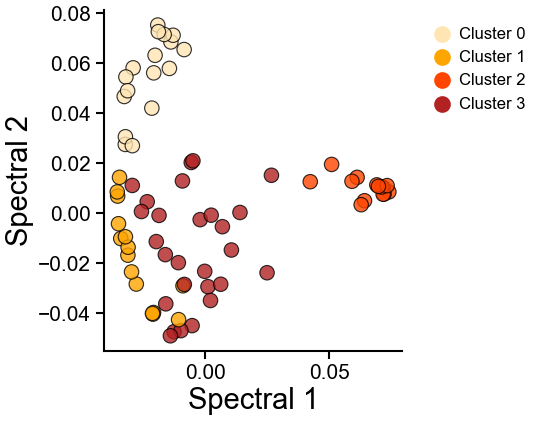

In [46]:
# plot clusters
sc_labels = sc.fit_predict(pt_embeddings[outcome_mask])

# make a color palette for 4 clusters using oranges, custom colors
custom_palette = {
    0: '#FFE5B4',
    1: '#FFA500',
    2: '#FF4500',
    3: '#B22222',
}

fig, ax = plt.subplots(1, 1, figsize=(50*MM_TO_IN, 40*MM_TO_IN))
sns.scatterplot(
    x=pt_embeddings_reduced[outcome_mask, 0],
    y=pt_embeddings_reduced[outcome_mask, 1],
    hue=sc_labels,
    ax=ax,
    palette=custom_palette,
    s=12,
    alpha=0.8,
    edgecolor='k',
)
ax.set_xlabel(f'{reducer_name} 1')
ax.set_ylabel(f'{reducer_name} 2')

# move the legend outside
handles, labels = ax.get_legend_handles_labels()
# add cluster to labels
labels = [f"Cluster {i}" for i in labels]
ax.legend(handles=handles, labels=labels, fontsize=4, markerscale=0.5, loc='upper left', bbox_to_anchor=(1.05, 1))

# save
fig.savefig(ospj(CONFIG.fig_dir, "outcome_clusters.pdf"), dpi=300, bbox_inches='tight', transparent=True)

### Patient seizure dissimilarity vs outcome

In [53]:
pt_level_metadata['ieeg_isFocal'].value_counts()

1.0    71
0.0    31
Name: ieeg_isFocal, dtype: int64

/mnt/leif/littlab/users/pattnaik/conda/envs/cis522/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/leif/littlab/users/pattnaik/conda/envs/cis522/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/mnt/leif/littlab/users/pattnaik/conda/envs/cis522/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/leif/littlab/users/pattnaik/conda/envs/cis522/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/mnt/leif/littlab/users/pattnaik/conda/envs/cis522/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dty

p-value: 0.381
1.0    71
0.0    31
Name: ieeg_isFocal, dtype: int64


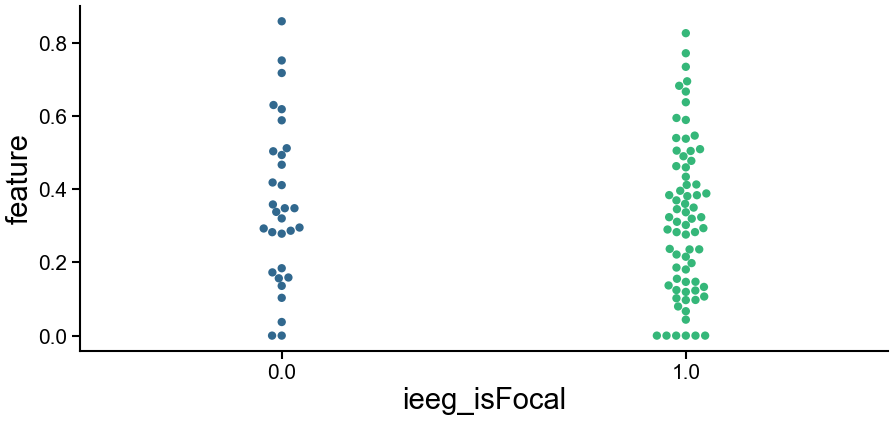

In [54]:
def compute_sd(points):
    # Compute the mean for each dimension
    mean_vals = np.mean(points, axis=0)
    
    # Compute the sum of squared differences from the mean for each dimension
    sum_squared_diffs = np.sum((points - mean_vals) ** 2, axis=0)
    
    # Compute the standard deviation for each dimension
    n = points.shape[0]
    sd = np.sqrt(np.sum(sum_squared_diffs)  / n)
    
    return sd

pt_dist_outcome = dict()
metadata = sz_metadata.copy().reset_index(drop=True)

for pt, group in metadata.groupby('Patient'):
    embeddings = sz_embeddings[group.index]
    # if len(embeddings) < 2:
    #     continue
    # compute average pairwise cosine similarity
    cos_sim = cosine_similarity(embeddings)
    cos_sim = cos_sim[np.triu_indices_from(cos_sim, k=1)]
    val = np.mean(cos_sim)

    # compute standard distance
    val = compute_sd(embeddings)
    
    pt_dist_outcome[pt] = val

pt_dist_outcome = pd.DataFrame(pt_dist_outcome, index=['feature']).T

pt_dist_outcome['outcome'] = pt_level_metadata['outcome']
pt_dist_outcome['target'] = pt_level_metadata['target']
pt_dist_outcome['ieeg_isFocal'] = pt_level_metadata['ieeg_isFocal']

pt_dist_outcome = pt_dist_outcome

fig, ax = plt.subplots(1, 1, figsize=(80*MM_TO_IN, 40*MM_TO_IN))
sns.swarmplot(
    x='ieeg_isFocal',
    y='feature',
    data=pt_dist_outcome,
    ax=ax,
    palette='viridis',
    s=2,
)
from scipy.stats import ttest_ind, mannwhitneyu

_, p_val = mannwhitneyu(
    pt_dist_outcome.query('(ieeg_isFocal == 0)')['feature'],
    pt_dist_outcome.query('(ieeg_isFocal == 1) and (outcome == "good")')['feature'],
    # pt_dist_outcome.query('(ieeg_isFocal == 1)')['feature'],
)
print(f"p-value: {p_val:.3f}")
print(pt_dist_outcome.ieeg_isFocal.value_counts())

p-value: 0.200
p-value: 0.088


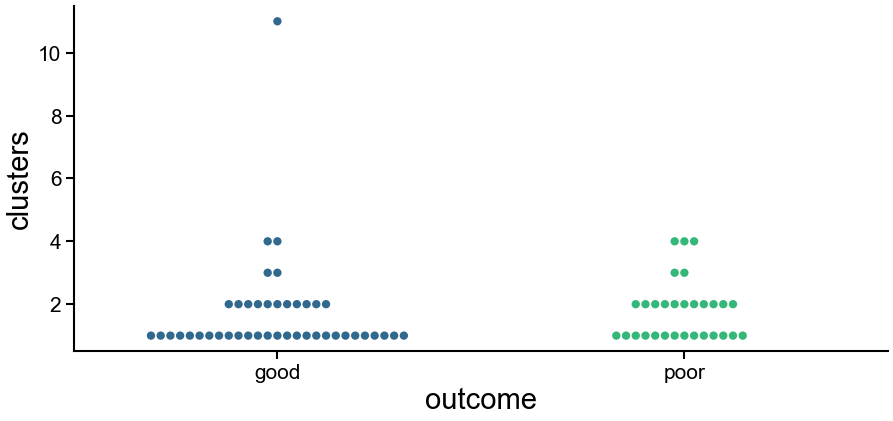

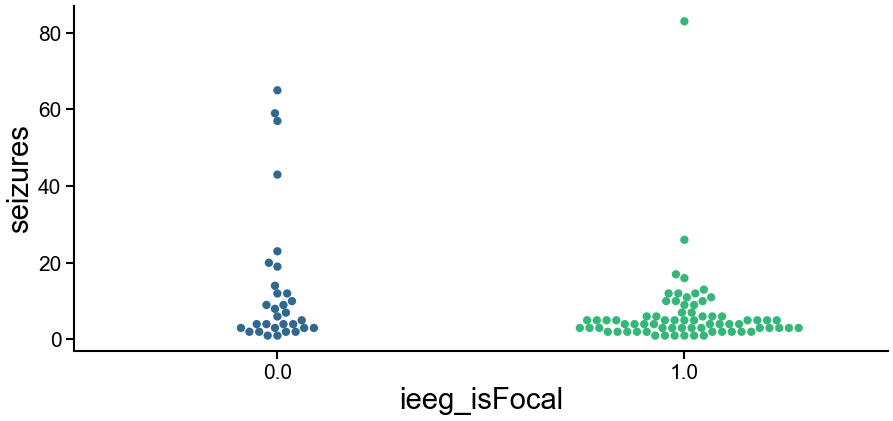

In [55]:
pt_dist_outcome['seizures'] = patient_to_clusters['seizures']
pt_dist_outcome['clusters'] = patient_to_clusters['clusters']

fig, ax = plt.subplots(1, 1, figsize=(80*MM_TO_IN, 40*MM_TO_IN))
sns.swarmplot(
    x='outcome',
    y='clusters',
    data=pt_dist_outcome.query('outcome != ""'),
    ax=ax,
    palette='viridis',
    s = 2,
)

_, p_val = mannwhitneyu(
    pt_dist_outcome.query('(outcome != "") and (outcome == "good")')['clusters'],
    pt_dist_outcome.query('(outcome != "") and (outcome == "poor")')['clusters'],
)
print(f"p-value: {p_val:.3f}")

fig, ax = plt.subplots(1, 1, figsize=(80*MM_TO_IN, 40*MM_TO_IN))
sns.swarmplot(
    x='ieeg_isFocal',
    y='seizures',
    data=pt_dist_outcome,
    ax=ax,
    palette='viridis',
    s = 2,
)

_, p_val = mannwhitneyu(
    pt_dist_outcome.query('(ieeg_isFocal == 0)')['seizures'],
    pt_dist_outcome.query('(ieeg_isFocal == 1)')['seizures'],
    # pt_dist_outcome.query('(ieeg_isFocal == 1)')['clusters'],
)
print(f"p-value: {p_val:.3f}")


### Seizure similarity vs time

In [56]:
embedding_dist = []
time_diff = []
pts = []

for pt, group in metadata.groupby("Patient"):
    if len(group) < 5:
        continue
    embedding_dist.extend(pdist(sz_embeddings[group.index], metric='cosine'))
    times = group.start
    times = np.abs(times[:, np.newaxis] - times[np.newaxis, :])
    time_diff.extend(times[np.triu_indices_from(times, k=1)])
    pts.extend([pt] * len(times[np.triu_indices_from(times, k=1)]))

similarity_time_df = pd.DataFrame({
    "embedding_dist": embedding_dist,
    "time_diff": time_diff,
    "pt": pts
})

# convert time_diff from seconds to days
similarity_time_df['time_diff'] = similarity_time_df['time_diff'] / (60*60*24)
# convert pt to categorical
similarity_time_df['pt'] = similarity_time_df['pt'].astype('category')

# linear mixed effects model
md = smf.mixedlm("embedding_dist ~ time_diff", similarity_time_df, groups=similarity_time_df["pt"], re_formula="~time_diff")
endog = similarity_time_df['embedding_dist']
exog = similarity_time_df['time_diff']
groups = similarity_time_df["pt"]
mdf = md.fit()
print(mdf.summary())


/tmp/ipykernel_10614/709975029.py:10: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  times = np.abs(times[:, np.newaxis] - times[np.newaxis, :])


            Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: embedding_dist
No. Observations:   12132   Method:             REML          
No. Groups:         51      Scale:              0.0388        
Min. group size:    10      Log-Likelihood:     2351.8469     
Max. group size:    3403    Converged:          Yes           
Mean group size:    237.9                                     
--------------------------------------------------------------
                      Coef. Std.Err.   z   P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept             0.191    0.024 7.977 0.000  0.144  0.238
time_diff             0.047    0.012 3.863 0.000  0.023  0.071
Group Var             0.026    0.030                          
Group x time_diff Cov 0.005    0.011                          
time_diff Var         0.005    0.009                          



/mnt/leif/littlab/users/pattnaik/conda/envs/cis522/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


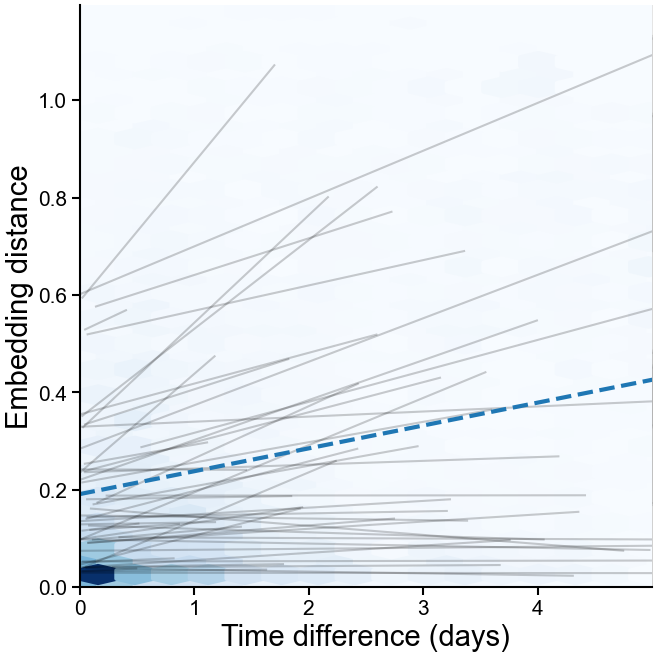

In [57]:
# Extract fixed effects
fixed_effects = mdf.fe_params
random_effects = mdf.random_effects
cov_re = mdf.cov_re

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(60*MM_TO_IN, 60*MM_TO_IN))

# Plot fitted lines for each patient
x_vals = np.linspace(similarity_time_df['time_diff'].min(), similarity_time_df['time_diff'].max(), 100)
for patient in similarity_time_df['pt'].unique():
    # Get the random effects for the patient
    random_effect = random_effects[patient]
    intercept = random_effect['Group']
    slope = random_effect['time_diff']

    x_vals = np.linspace(similarity_time_df.query('pt == @patient')['time_diff'].min(), similarity_time_df.query('pt == @patient')['time_diff'].max(), 100)

    se_slope = np.sqrt(cov_re.iloc[0, 0])
    se_intercept = np.sqrt(cov_re.iloc[1, 1])
    y_se = np.sqrt(se_slope**2 + (x_vals*se_intercept)**2)


    # Calculate fitted values
    y_vals = (fixed_effects['Intercept'] + intercept) + (fixed_effects['time_diff'] + slope) * x_vals

    # Plot the fitted line
    ax.plot(x_vals, y_vals, label=f'Fitted line for patient {patient}', lw=0.5, color='k', alpha=0.2)
    ax.fill_between(x_vals, y_vals - y_se, y_vals + y_se, color='grey', alpha=0.2)

# plot fixed effects
x_vals = np.linspace(similarity_time_df['time_diff'].min(), similarity_time_df['time_diff'].max(), 100)
y_vals = fixed_effects['Intercept'] + fixed_effects['time_diff'] * x_vals
ax.plot(x_vals, y_vals, label='Fixed effects', lw=1, color='tab:blue', linestyle='--')


ax.hexbin(
    x=similarity_time_df['time_diff'],
    y=similarity_time_df['embedding_dist'],
    cmap="Blues",
    gridsize=50,
)

ax.set_xlabel('Time difference (days)')
ax.set_ylabel('Embedding distance')
# ax.legend()
ax.set_xlim(0, np.percentile(similarity_time_df['time_diff'], 99))
ax.set_ylim(0, np.percentile(similarity_time_df['embedding_dist'], 99))

fig.savefig(ospj(CONFIG.fig_dir, 'embedding_time.pdf'), transparent=True, dpi=300, bbox_inches='tight')

# plt.show()


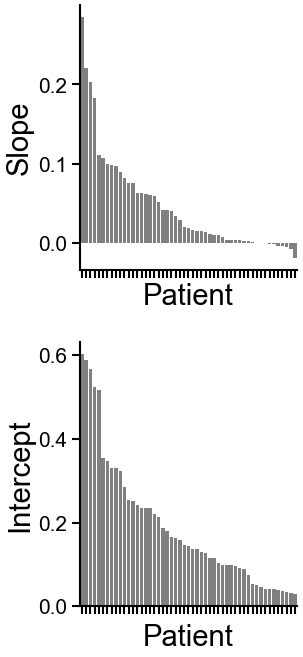

In [58]:
# bar plot of each patient's slope
patient_slopes = pd.DataFrame({
    'patient': list(random_effects.keys()),
    'slope': [random_effects[patient]['time_diff'] + fixed_effects['time_diff'] for patient in random_effects.keys()]
})
patient_slopes = patient_slopes.sort_values('slope', ascending=False)

patient_intercepts = pd.DataFrame({
    'patient': list(random_effects.keys()),
    'intercept': [random_effects[patient]['Group'] + fixed_effects['Intercept'] for patient in random_effects.keys()]
})
patient_intercepts = patient_intercepts.sort_values('intercept', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(30*MM_TO_IN, 30*MM_TO_IN*2), sharex=True)

sns.barplot(
    x='patient',
    y='slope',
    data=patient_slopes,
    ax=axes[0],
    # palette='Blues_r'
    color='grey'
)
axes[0].set_ylabel('Slope')
sns.barplot(
    x='patient',
    y='intercept',
    data=patient_intercepts,
    ax=axes[1],
    # palette='Blues_r'
    color='grey'
)
axes[1].set_ylabel('Intercept')
for ax in axes.flat:
    ax.set_xticklabels(["" for _ in axes[1].get_xticklabels()])
    ax.set_xlabel('Patient')

fig.savefig(ospj(CONFIG.fig_dir, 'embedding_time_slope_intercept.pdf'), transparent=True, dpi=300, bbox_inches='tight')

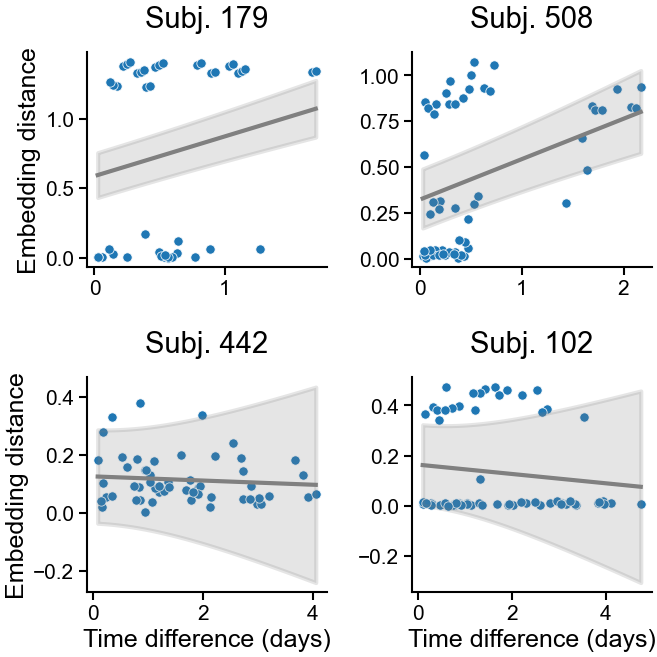

In [59]:
# pull out examples of high and low slope patients
N_EXAMPLES = 2

high_slope_patients = patient_slopes['patient'].head(N_EXAMPLES)
low_slope_patients = patient_slopes['patient'].tail(N_EXAMPLES)

# plot embedding vs time for high and low slope patients
fig, axes = plt.subplots(2, N_EXAMPLES, figsize=(30*MM_TO_IN*N_EXAMPLES, 30*MM_TO_IN*2))

for patients, ax in zip([high_slope_patients, low_slope_patients], axes):
    for patient, ax in zip(patients, ax):
        patient_data = similarity_time_df.query('pt == @patient')
        # ax.scatter(
        #     x=patient_data['time_diff'],
        #     y=patient_data['embedding_dist'],
        #     s=1,
        #     color='grey',
        #     # set edge color to white
        #     edgecolor='k'
        # )
        sns.scatterplot(
            x='time_diff',
            y='embedding_dist',
            data=patient_data,
            ax=ax,
            s=5,
            color='tab:blue',
            # edgecolor='k'
        )
        ax.set_title(f"Subj. {int(patient[-4:])}", fontsize=7)
        ax.set_xlabel('Time difference (days)', fontsize=6)
        ax.set_ylabel('Embedding distance', fontsize=6)

        # plot the fitted line
        slope = random_effects[patient]['time_diff'] + fixed_effects['time_diff']
        intercept = random_effects[patient]['Group'] + fixed_effects['Intercept']

        x_vals = np.linspace(similarity_time_df.query('pt == @patient')['time_diff'].min(), similarity_time_df.query('pt == @patient')['time_diff'].max(), 100)
        y_vals = intercept + slope * x_vals
        ax.plot(x_vals, y_vals, label='Fitted line', lw=1, color='grey')

        cov_re = mdf.cov_re
        se_slope = np.sqrt(cov_re.iloc[0, 0])
        se_intercept = np.sqrt(cov_re.iloc[1, 1])
        y_se = np.sqrt(se_slope**2 + (x_vals*se_intercept)**2)

        ax.fill_between(x_vals, y_vals - y_se, y_vals + y_se, color='grey', alpha=0.2)

# remove x labels for top row and y labels for non-left columns
for ax_row in axes:
    ax_row[0].set_ylabel('Embedding distance', fontsize=6)
    for ax in ax_row[1:]:
        ax.set_ylabel('')

for ax in axes[0]:
    ax.set_xlabel('')

fig.savefig(ospj(CONFIG.fig_dir, 'embedding_time_slope_intercept_examples.pdf'), transparent=True, dpi=300, bbox_inches='tight')

## Seizure onset channels

In [20]:
print(f"regions shape: {all_regs.shape}")
print(f"eeg shape: {all_eegs.shape}")

regions shape: (878, 150)
eeg shape: (878, 150, 2560)


In [21]:
# compute windowed broadband energy for each 1 s window with 0.25 s overlap
fs = 256
nperseg = fs
noverlap = fs - int(fs * 0.25)

# Parameters
sampling_rate = 256  # Hz
window_length = sampling_rate  # 1 second window (256 samples)
step_size = int(sampling_rate * 0.25)  # 0.25 second overlap (64 samples)
num_windows = (all_eegs.shape[2] - window_length) // step_size + 1

# Create the sliding windows
shape = (all_eegs.shape[0], all_eegs.shape[1], num_windows, window_length)
strides = (all_eegs.strides[0], all_eegs.strides[1], step_size * all_eegs.strides[2], all_eegs.strides[2])
windows = np.lib.stride_tricks.as_strided(all_eegs, shape=shape, strides=strides)

# Compute the line length using vectorized operations
diffs = np.abs(np.diff(windows, axis=-1))
line_lengths = np.sum(diffs, axis=-1)

# line_lengths now contains the line length values for each window, channel, and EEG


In [22]:
# normalize to the first 2 seconds (8 windows) (- mean and divide by std)
line_lengths_norm = (line_lengths - line_lengths[..., :8].mean(axis=-1, keepdims=True)) / line_lengths[..., :8].std(axis=-1, keepdims=True)

/tmp/ipykernel_57903/2863972337.py:2: RuntimeWarning: invalid value encountered in divide
  line_lengths_norm = (line_lengths - line_lengths[..., :8].mean(axis=-1, keepdims=True)) / line_lengths[..., :8].std(axis=-1, keepdims=True)


Text(0.5, 27.33333333333331, 'Window')

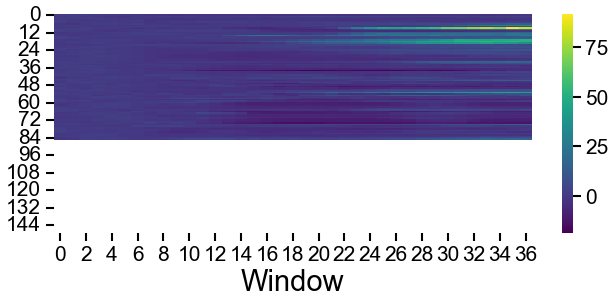

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(60*MM_TO_IN, 30*MM_TO_IN))
sns.heatmap(line_lengths_norm[30], ax=ax, cmap='viridis')
ax.set_xlabel('Window')

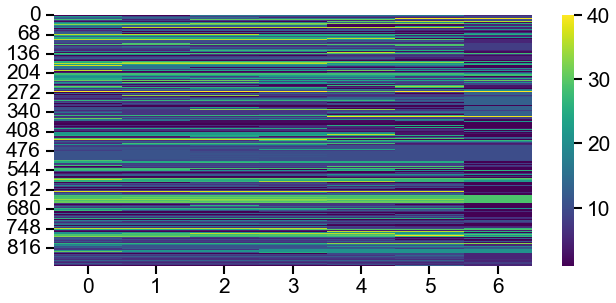

In [24]:
thresholds = np.array([2, 3, 4, 5, 10, 15, 50])
onset_across_thresh = []

# find the channels that exceed the threshold the most windows for each seizure
for thresh in thresholds:
    n_exceed = (line_lengths_norm > thresh).sum(axis=-1)
    # get the argmax for each seizure
    max_ch = np.argmax(n_exceed, axis=1)
    # apply to each seizure to get regs
    max_regs = np.array([all_regs[i, max_ch[i]] for i in range(len(max_ch))])
    onset_across_thresh.append(max_regs)

onset_across_thresh = np.array(onset_across_thresh)

fig, ax = plt.subplots(1, 1, figsize=(60*MM_TO_IN, 30*MM_TO_IN))
sns.heatmap(onset_across_thresh.T, ax=ax, cmap='viridis')


# likely onset is most common onset across thresholds
likely_onset = np.array([np.argmax(np.bincount(onset_across_thresh[:, i])) for i in range(onset_across_thresh.shape[1])])
likely_onset = unique_regs.loc[likely_onset - 1]["reg"].values

In [25]:
likely_onset_gross = []
for onset_reg in likely_onset:
    if ("_L" in onset_reg) and ("Frontal" in onset_reg):
        likely_onset_gross.append("Left Frontal")
    elif ("_R" in onset_reg) and ("Frontal" in onset_reg):
        likely_onset_gross.append("Right Frontal")
    elif ("_L" in onset_reg) and ("Temporal" in onset_reg):
        likely_onset_gross.append("Left Temporal")
    elif ("_R" in onset_reg) and ("Temporal" in onset_reg):
        likely_onset_gross.append("Right Temporal")
    elif ("_L" in onset_reg):
        likely_onset_gross.append("Left Other")
    elif ("_R" in onset_reg):
        likely_onset_gross.append("Right Other")
    else:
        likely_onset_gross.append("Other")

likely_onset_gross = np.array(likely_onset_gross)


In [26]:
pd.Series(likely_onset_gross).value_counts().to_frame()

,0
Left Other,298
Left Frontal,166
Left Temporal,156
Right Other,128
Right Temporal,68
Right Frontal,62


In [27]:
pd.Series(likely_onset).value_counts().to_frame()

,0
Amyg_Hipp_L,122
Frontal_inf_All_L,86
Temporal_Sup_L,65
Frontal_Mid_All_L,61
Temporal_Mid_L,51
Amyg_Hipp_R,40
Temporal_Inf_L,40
SupraMarginal_Angular_L,31
Temporal_Inf_R,28
Precentral_L,26


NameError: name 'silhouette_score' is not defined

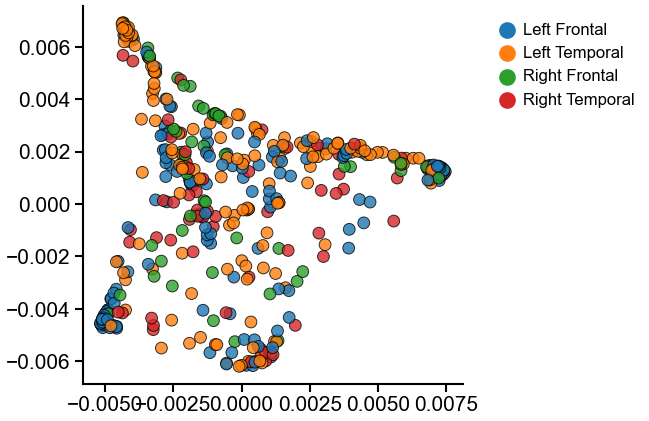

In [28]:
# mask is for top 4 occuring regions
mask = np.isin(likely_onset, pd.Series(likely_onset).value_counts().head(8).index)
mask = np.isin(likely_onset_gross, ["Left Temporal", "Right Temporal", "Left Frontal", "Right Frontal"])
# mask = np.isin(likely_onset_gross, ["Left Temporal", "Left Frontal"])


# mask = np.ones(len(likely_onset), dtype=bool)

# plot the embeddings and color by likely onset
fig, ax = plt.subplots(1, 1, figsize=(60*MM_TO_IN, 40*MM_TO_IN))
sns.scatterplot(
    x=sz_embeddings_reduced[mask, 0],
    y=sz_embeddings_reduced[mask, 1],
    hue=likely_onset_gross[mask],
    ax=ax,
    # palette='tab20',
    s=8,
    alpha=0.8,
    edgecolor='k',
)
# move legend outside
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, fontsize=4, markerscale=0.5, loc='upper left', bbox_to_anchor=(1.05, 1))

# test the clustering of the likely onset regions
true_partition = likely_onset_gross[mask]

true_score = silhouette_score(sz_embeddings[mask], true_partition, metric='cosine')

n_bootstraps = 1000
null_scores = np.zeros(n_bootstraps)
for i_bootstrap in range(n_bootstraps):
    # pick a random partition
    random_partition = np.random.permutation(true_partition)
    null_scores[i_bootstrap] = silhouette_score(sz_embeddings[mask], random_partition, metric='cosine')

p_val = (null_scores > true_score).sum() / n_bootstraps

print(f"Likely onset regions: {p_val:.3f}")

balanced_accuracy_score: 0.326


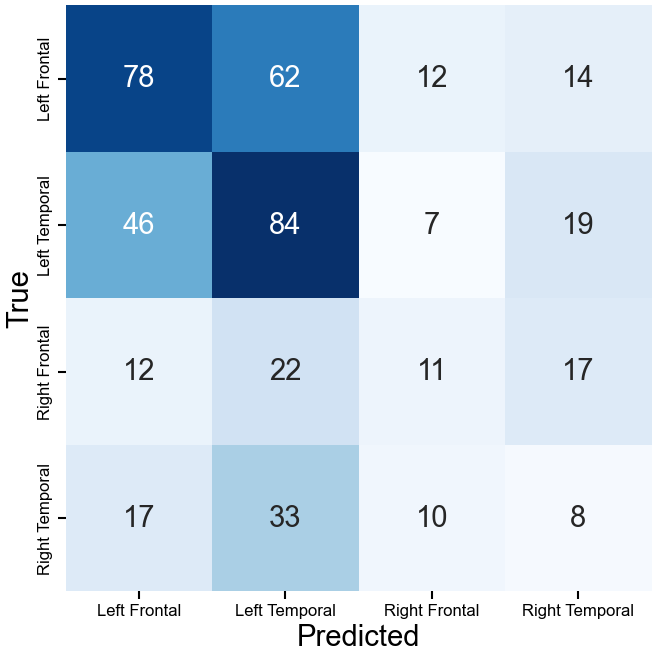

In [ ]:
X = sz_embeddings[mask]
y = likely_onset_gross[mask]

# apply cross val predict
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=42)
y_pred = cross_val_predict(clf, X, y, cv=10)

# compute balanced accuracy
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score(y, y_pred)

# plot the confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

conf_mat = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(1, 1, figsize=(60*MM_TO_IN, 60*MM_TO_IN))
sns.heatmap(
    conf_mat,
    ax=ax,
    annot=True,
    cmap='Blues',
    cbar=False,
    square=True,
    xticklabels=np.unique(y),
    yticklabels=np.unique(y),
)
# make x and y tick labels smaller
ax.set_xticklabels(ax.get_xticklabels(), fontsize=4); ax.set_yticklabels(ax.get_yticklabels(), fontsize=4)

ax.set_xlabel('Predicted')
ax.set_ylabel('True')

print(f"balanced_accuracy_score: {balanced_accuracy_score(y, y_pred):.3f}")
# compute auc
# from sklearn.metrics import roc_auc_score
# y_int = pd.Series(y).map({"Left Temporal": 0, "Left Frontal": 1})
# y_pred_int = pd.Series(y_pred).map({"Left Temporal": 0, "Left Frontal": 1})

# print(f"roc_auc_score: {roc_auc_score(y_int, y_pred_int):.3f}")

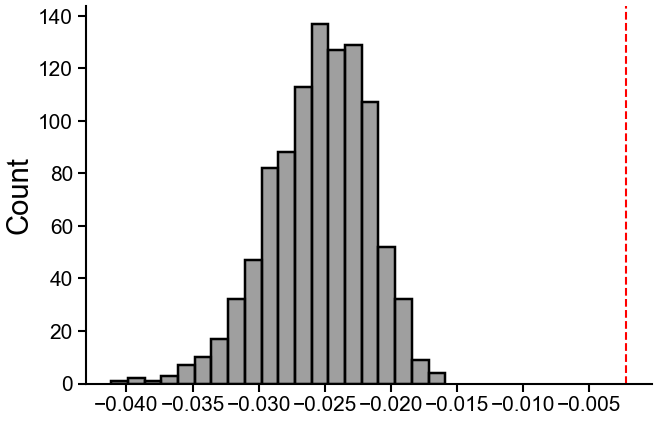

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(60*MM_TO_IN, 40*MM_TO_IN))
sns.histplot(
    null_scores,
    ax=ax,
    bins=20,
    color='grey',
)
ax.axvline(true_score, color='r', linestyle='--')

#### Clinical SOZ Labels

In [29]:
soz_elecs = pd.read_csv("/mnt/leif/littlab/users/pattnaik/ieeg_sz_embedding/data/metadata/soz_electrodes.csv")

display(soz_elecs)

,rid,soz_electrode
0,sub-RID0013,MST01
1,sub-RID0013,MST02
2,sub-RID0013,MST03
3,sub-RID0013,RG50
4,sub-RID0013,RG51
...,...,...
1265,sub-RID0700,RT04
1266,sub-RID0700,RT05
1267,sub-RID0700,RT06
1268,sub-RID0785,LB03


In [30]:
all_regs.shape

(878, 150)

In [31]:
is_soz = np.zeros_like(all_regs, dtype=bool)

for pt, group in soz_elecs.groupby('rid'):
    soz_ch_names = group['soz_electrode'].values

    pt_idx = sz_metadata.reset_index(drop=True).query('Patient == @pt').index
    if len(pt_idx) == 0:
        continue
    # print(pt, pt_idx)

    ch_names = [all_ch_names[i] for i in pt_idx]

    # display(ch_names)
    nonzero_eegs = all_eegs[pt_idx]
    nonzero_eegs = np.all(nonzero_eegs != 0, axis=(0, 2)).sum()
    
    true_ch_names = [names for names in ch_names if len(names) == nonzero_eegs]
    if pt == 'sub-RID0309':
        continue
    if pt == 'sub-RID0382':
        continue
    if pt == 'sub-RID0522':
        continue

    assert len(true_ch_names) != 0, f"Nonzero eegs: {nonzero_eegs}, ch_names: {[len(i) for i in ch_names]} {sz_metadata.loc[pt_idx, 'Patient'].values}"

    # assert all([i == nonzero_eegs for i in [len(i) for i in ch_names]]), f"Nonzero eegs: {nonzero_eegs}, ch_names: {[len(i) for i in ch_names]} {sz_metadata.loc[pt_idx, 'Patient'].values}"
    for i, ch_name in enumerate(true_ch_names[0]):
        ch_name1 = ch_name.split('-')[0]
        ch_name2 = ch_name.split('-')[1]

        if (ch_name1 in soz_ch_names) or (ch_name2 in soz_ch_names):
            is_soz[pt_idx, i] = True


In [32]:
unique_regs

,reg
0,Amyg_Hipp_L
1,ParaHippocampal_L
2,thalam_limbic_L
3,Insula_L
4,Temporal_Inf_L
5,Temporal_Mid_L
6,Temporal_Sup_L
7,Frontal_Mid_All_L
8,Frontal_Sup_All_L
9,Frontal_inf_All_L


In [33]:
mask_idx = []

soz_regs = {}
for reg in unique_regs.reg:
    soz_regs[reg] = []

for i, sample in enumerate(is_soz):
    soz_regs_sample = all_regs[i][is_soz[i]]

    if len(soz_regs_sample) == 0:
        continue

    soz_regs_sample = unique_regs.iloc[soz_regs_sample - 1].reg.values
    for reg in soz_regs_sample:
        soz_regs[reg].append(i)

    mask_idx.append(i)
soz_regs = {k: v for k, v in soz_regs.items() if len(v) > 0}

# sort by number of patients
# soz_regs = {k: v for k, v in sorted(soz_regs.items(), key=lambda item: len(item[1]), reverse=True)}
display(soz_regs)
mask_idx = np.array(mask_idx)

{'Amyg_Hipp_L': [34,
  34,
  35,
  35,
  36,
  36,
  37,
  37,
  38,
  38,
  39,
  39,
  40,
  40,
  41,
  41,
  42,
  42,
  43,
  43,
  44,
  44,
  45,
  45,
  46,
  46,
  47,
  47,
  48,
  48,
  49,
  49,
  50,
  50,
  51,
  51,
  52,
  52,
  53,
  53,
  54,
  54,
  55,
  55,
  56,
  56,
  57,
  57,
  58,
  58,
  59,
  59,
  60,
  60,
  61,
  61,
  62,
  62,
  63,
  63,
  64,
  64,
  65,
  65,
  66,
  66,
  67,
  67,
  68,
  68,
  69,
  69,
  70,
  70,
  71,
  71,
  72,
  72,
  73,
  73,
  74,
  74,
  75,
  75,
  76,
  76,
  77,
  77,
  78,
  78,
  79,
  79,
  80,
  80,
  81,
  81,
  82,
  82,
  83,
  83,
  84,
  84,
  85,
  85,
  86,
  86,
  87,
  87,
  88,
  88,
  89,
  89,
  90,
  90,
  91,
  91,
  92,
  92,
  93,
  93,
  94,
  94,
  95,
  95,
  96,
  96,
  97,
  97,
  98,
  98,
  140,
  140,
  141,
  141,
  142,
  142,
  143,
  143,
  158,
  159,
  160,
  174,
  175,
  176,
  177,
  178,
  179,
  180,
  181,
  182,
  182,
  182,
  182,
  183,
  183,
  183,
  183,
  184,
  184,
  

In [34]:
unique_regs

,reg
0,Amyg_Hipp_L
1,ParaHippocampal_L
2,thalam_limbic_L
3,Insula_L
4,Temporal_Inf_L
5,Temporal_Mid_L
6,Temporal_Sup_L
7,Frontal_Mid_All_L
8,Frontal_Sup_All_L
9,Frontal_inf_All_L


In [35]:
pt = sz_metadata.iloc[10].Patient
soz_elecs.query(f'rid == @pt')

,rid,soz_electrode
268,sub-RID0102,APD01
269,sub-RID0102,APD02
270,sub-RID0102,APD03
271,sub-RID0102,APD04
272,sub-RID0102,LPF02
273,sub-RID0102,LPF03
274,sub-RID0102,PPD01
275,sub-RID0102,PPD02
276,sub-RID0102,PPD03
277,sub-RID0102,PPD04


In [36]:
def compute_mean_dist(embeddings):
    centroid = embeddings.mean(axis=0)
    dist = np.linalg.norm(embeddings - centroid, axis=1)
    return dist.mean()

In [37]:
len(soz_regs)

38

In [38]:
from scipy.stats import norm
# set seed
np.random.seed(42)

# fig, axes = plt.subplots(2, 19, figsize=(120*MM_TO_IN, 30*MM_TO_IN))

selected_regs = ["Temporal_Inf_L", "Temporal_Inf_R", "Frontal_Mid_All_L", "Frontal_Mid_All_R"]

good_names = {
    "Temporal_Inf_L": "Left Inferior Temporal",
    "Temporal_Inf_R": "Right Inferior Temporal",
    "Frontal_Mid_All_L": "Left Middle Frontal",
    "Frontal_Mid_All_R": "Right Middle Frontal",
}

# test clustering of each reg
for i, (reg, idx) in enumerate(soz_regs.items()):
    if reg not in selected_regs:
        continue
    ax = axes.flatten()[i]
    idx = np.unique(idx)
    true_embeddings = sz_embeddings[idx]

    true_clustering = compute_sd(true_embeddings)
    true_clustering = compute_mean_dist(true_embeddings)

    fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))

    
    n_bootstraps = 1000
    null_clustering = np.zeros(n_bootstraps)
    for i_bootstrap in range(n_bootstraps):
        # pick a random partition
        random_partition = np.random.choice(mask_idx, size=len(idx), replace=True)

        random_embeddings = sz_embeddings[random_partition]
        null_clustering[i_bootstrap] = compute_sd(random_embeddings)
        null_clustering[i_bootstrap] = compute_mean_dist(random_embeddings)
    
    mean = null_clustering.mean()
    std = null_clustering.std()

    # get p value from gaussian approximation
    p_val = (norm.cdf(true_clustering, loc=mean, scale=std))
    # Bonferroni correction
    p_val = p_val * len(soz_regs)
    print(f"{reg}: {p_val}")

    # sns.histplot(null_clustering, bins=20, color='grey')
    # plt.axvline(true_clustering, color='r', linestyle='--')


    sns.scatterplot(
        x=sz_embeddings_reduced[mask_idx, 0],
        y=sz_embeddings_reduced[mask_idx, 1],
        ax=ax,
        s=3,
        alpha=0.1,
        edgecolor='k',
        color='grey',
    )
    sns.scatterplot(
        x=sz_embeddings_reduced[idx, 0],
        y=sz_embeddings_reduced[idx, 1],
        ax=ax,
        s=3,
        alpha=0.8,
        edgecolor='k',
        color='tab:blue',
    )
    ax.set_title(good_names[reg], fontsize=7)
    # turn off all axes
    ax.axis('off')
    # make axis square
    ax.set_aspect('equal')

    fig.savefig(ospj(CONFIG.fig_dir, f'{reg}_embedding.pdf'), transparent=True, dpi=300, bbox_inches='tight')

    # break

NameError: name 'axes' is not defined

Left Frontal: 413
Right Frontal: 19
Left Temporal: 245
Right Temporal: 109
[413, 19, 245, 109]
Accuracy: 0.683206106870229


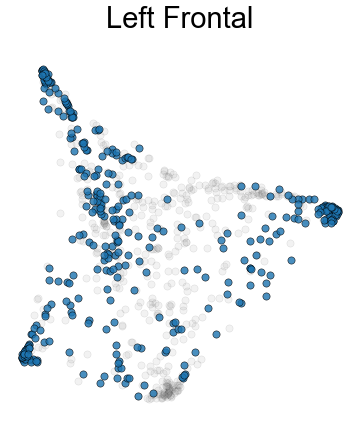

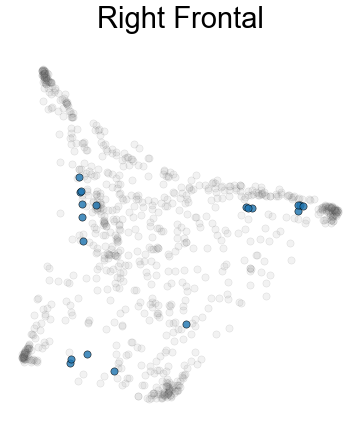

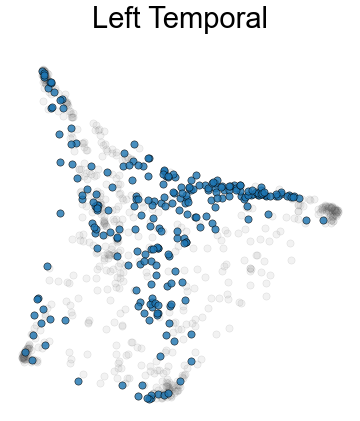

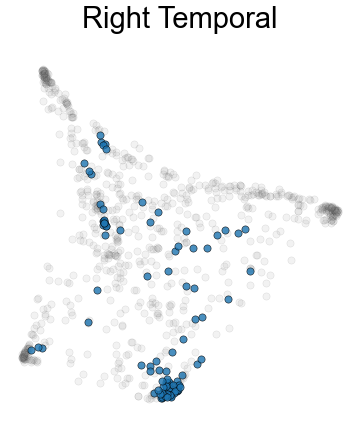

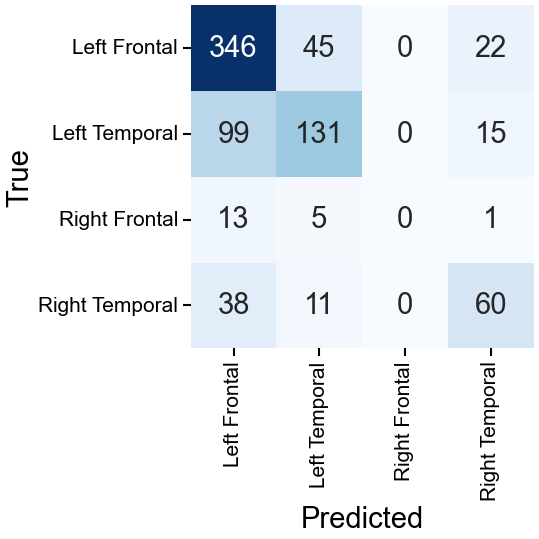

In [71]:
labels = {
    "Left Frontal": [],
    "Right Frontal": [],
    "Left Temporal": [],
    "Right Temporal": [],
}

for i, sample in enumerate(is_soz):
    soz_regs_sample = all_regs[i][is_soz[i]]

    if len(soz_regs_sample) == 0:
        continue

    soz_regs_sample = unique_regs.iloc[soz_regs_sample - 1].reg.values
    
    n_lf = ["Frontal" in reg and "L" in reg for reg in soz_regs_sample].count(True)
    n_rf = ["Frontal" in reg and "R" in reg for reg in soz_regs_sample].count(True)
    n_lt = ["Temporal" in reg and "L" in reg for reg in soz_regs_sample].count(True)
    n_rt = ["Temporal" in reg and "R" in reg for reg in soz_regs_sample].count(True)

    # set label to max
    max_idx = np.argmax([n_lf, n_rf, n_lt, n_rt])
    if max_idx == 0:
        labels["Left Frontal"].append(i)
    elif max_idx == 1:
        labels["Right Frontal"].append(i)
    elif max_idx == 2:
        labels["Left Temporal"].append(i)
    elif max_idx == 3:
        labels["Right Temporal"].append(i)


for reg, mask in labels.items():
    print(f"{reg}: {len(mask)}")
    fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))
    sns.scatterplot(
        x=sz_embeddings_reduced[:, 0],
        y=sz_embeddings_reduced[:, 1],
        ax=ax,
        s=3,
        alpha=0.1,
        edgecolor='k',
        color='grey',
    )
    sns.scatterplot(
        x=sz_embeddings_reduced[mask, 0],
        y=sz_embeddings_reduced[mask, 1],
        ax=ax,
        s=3,
        alpha=0.8,
        edgecolor='k',
        color='tab:blue',
    )
    ax.set_title(reg, fontsize=7)
    # turn off all axes
    ax.axis('off')
    # make axis square
    ax.set_aspect('equal')

    fig.savefig(ospj(CONFIG.fig_dir, f'{reg}_embedding.pdf'), transparent=True, dpi=300, bbox_inches='tight')


print([len(v) for k, v in labels.items()])

# make a classifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import balanced_accuracy_score, accuracy_score

X = np.concatenate([sz_embeddings[v] for k, v in labels.items()])
y = np.concatenate([[k] * len(v) for k, v in labels.items()])

clf = LogisticRegression()
y_pred = cross_val_predict(clf, X, y, cv=10)

acc = accuracy_score(y, y_pred)

print(f"Accuracy: {acc}")

# plot the confusion matrix
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(1, 1, figsize=(50*MM_TO_IN, 50*MM_TO_IN))
sns.heatmap(
    conf_mat,
    ax=ax,
    annot=True,
    cmap='Blues',
    cbar=False,
    square=True,
    xticklabels=np.unique(y),
    yticklabels=np.unique(y),
    fmt='d'
)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')

fig.savefig(ospj(CONFIG.fig_dir, 'soz_region_classifier_confusion_matrix.pdf'), transparent=True, dpi=300, bbox_inches='tight')


In [79]:
X_tensor.shape

torch.Size([786, 128])

In [84]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# 1. Data Preparation
# --------------------------------------------------
# Replace the dummy data below with your actual data:
# X = sz_embeddings[mask]        # shape: (n_samples, n_features)
# y = likely_onset_gross[mask]     # e.g. array of strings like 'Left Frontal', etc.

np.random.seed(42)

# Encode string labels to integers
unique_labels = sorted(np.unique(y))
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
y_encoded = np.array([label_to_idx[label] for label in y])

# Convert to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

# --------------------------------------------------
# 2. Define the Lightning Module (Linear Classifier)
# --------------------------------------------------
class LinearClassifier(pl.LightningModule):
    def __init__(self, input_dim, num_classes, learning_rate=1e-3):
        super().__init__()
        self.save_hyperparameters()  # saves hyperparameters to self.hparams
        self.linear_1 = nn.Linear(input_dim, input_dim)
        self.linear = nn.Linear(input_dim, num_classes)

        self.loss_fn = nn.CrossEntropyLoss()
    
    def forward(self, x):
        x = self.linear_1(x)
        return self.linear(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log("train_loss", loss, on_epoch=True)
        return loss
    
    # Optional: define test_step if you wish to log test loss
    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.log("test_loss", loss, prog_bar=True)
        return {"loss": loss, "preds": preds, "targets": y}
    
    # predict_step is used by trainer.predict to generate outputs
    def predict_step(self, batch, batch_idx):
        x, _ = batch
        logits = self(x)
        preds = torch.argmax(logits, dim=1)
        return preds
    
    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return optimizer

# --------------------------------------------------
# 3. Hyperparameters and Cross-Validation Setup
# --------------------------------------------------
n_splits = 10       # 10-fold cross-validation
batch_size = 32
num_epochs = 500
learning_rate = 1e-3

kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
n_samples = X_tensor.shape[0]
y_pred_all = np.empty(n_samples, dtype=int)  # to store predictions for each sample

# --------------------------------------------------
# 4. Cross-Validation Loop Using PyTorch Lightning
# --------------------------------------------------
for fold, (train_idx, test_idx) in enumerate(kf.split(X_tensor)):
    print(f"--- Fold {fold+1}/{n_splits} ---")
    
    # Create TensorDatasets and DataLoaders for the current fold
    train_dataset = TensorDataset(X_tensor[train_idx], y_tensor[train_idx])
    test_dataset  = TensorDataset(X_tensor[test_idx],  y_tensor[test_idx])
    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader   = DataLoader(test_dataset, batch_size=batch_size)
    
    # Initialize the model
    model = LinearClassifier(input_dim=X_tensor.shape[1],
                             num_classes=len(unique_labels),
                             learning_rate=learning_rate)
    
    # Initialize the PyTorch Lightning Trainer
    trainer = pl.Trainer(
        max_epochs=num_epochs,
        logger=False,               # disable logging for simplicity
        enable_checkpointing=False, # disable checkpointing
        enable_progress_bar=False,   # disable progress bar if desired
       accelerator="auto", devices=1
    )
    
    # Train the model on the training split of the current fold
    trainer.fit(model, train_loader)
    
    # Use the trainer to predict on the test split
    predictions = trainer.predict(model, dataloaders=test_loader)
    # 'predictions' is a list of tensors (one per batch); concatenate them:
    preds_fold = torch.cat(predictions).cpu().numpy()
    
    # Store the predictions in their corresponding indices from the original dataset
    y_pred_all[test_idx] = preds_fold

# --------------------------------------------------
# 5. Compute and Print the Balanced Accuracy
# --------------------------------------------------
balanced_acc = balanced_accuracy_score(y_encoded, y_pred_all)
print(f"\nBalanced Accuracy: {balanced_acc:.3f}")


--- Fold 1/10 ---


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type             | Params
----------------------------------------------
0 | linear_1 | Linear           | 16.5 K
1 | linear   | Linear           | 516   
2 | loss_fn  | CrossEntropyLoss | 0     
----------------------------------------------
17.0 K    Trainable params
0         Non-trainable params
17.0 K    Total params
0.068     Total estimated model params size (MB)
/home1/z/zcxu/.local/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:236: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 64 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
`Trainer.fit` stopped: `max_epochs=500` reached.
LOCAL_R

--- Fold 2/10 ---


/home1/z/zcxu/.local/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:236: The dataloader, predict_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 64 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type             | Params
----------------------------------------------
0 | linear_1 | Linear           | 16.5 K
1 | linear   | Linear           | 516   
2 | loss_fn  | CrossEntropyLoss | 0     
----------------------------------------------
17.0 K    Trainable params
0         Non-trainable params
17.0 K    Total params
0.068     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=500` reached.
LOC

--- Fold 3/10 ---


...

--- Fold 9/10 ---


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type             | Params
----------------------------------------------
0 | linear_1 | Linear           | 16.5 K
1 | linear   | Linear           | 516   
2 | loss_fn  | CrossEntropyLoss | 0     
----------------------------------------------
17.0 K    Trainable params
0         Non-trainable params
17.0 K    Total params
0.068     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=500` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


--- Fold 10/10 ---


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type             | Params
----------------------------------------------
0 | linear_1 | Linear           | 16.5 K
1 | linear   | Linear           | 516   
2 | loss_fn  | CrossEntropyLoss | 0     
----------------------------------------------
17.0 K    Trainable params
0         Non-trainable params
17.0 K    Total params
0.068     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=500` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Balanced Accuracy: 0.811


<AxesSubplot:>

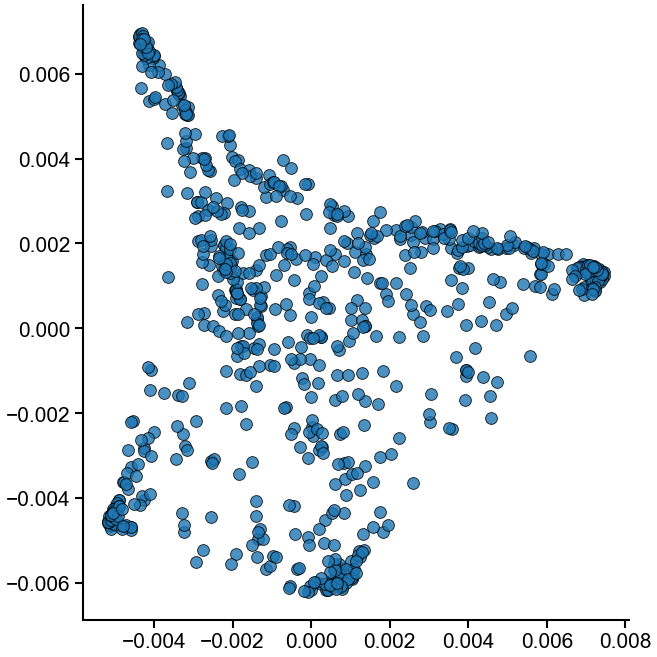

In [42]:
# mask is for top 4 occuring regions
mask = mask_idx
# mask = np.ones(len(likely_onset), dtype=bool)

# plot the embeddings and color by likely onset
fig, ax = plt.subplots(1, 1, figsize=(60*MM_TO_IN, 60*MM_TO_IN))
sns.scatterplot(
    x=sz_embeddings_reduced[mask, 0],
    y=sz_embeddings_reduced[mask, 1],
    ax=ax,
    # palette='tab20',
    s=8,
    alpha=0.8,
    edgecolor='k',
)


Accuracy: 0.8638676844783715
                precision    recall  f1-score   support

  Left Frontal       0.89      0.91      0.90       413
 Left Temporal       0.86      0.80      0.83       245
 Right Frontal       0.59      0.68      0.63        19
Right Temporal       0.83      0.84      0.84       109

      accuracy                           0.86       786
     macro avg       0.79      0.81      0.80       786
  weighted avg       0.86      0.86      0.86       786



Text(25.85695538057743, 0.5, 'True')

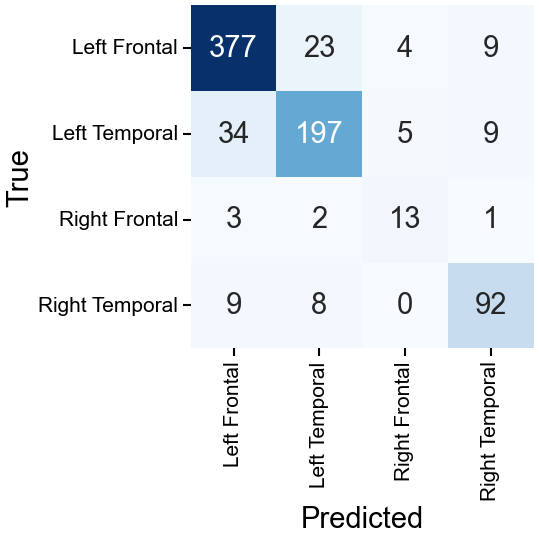

In [85]:
acc = accuracy_score(y_encoded, y_pred_all)

print(f"Accuracy: {acc}")

from sklearn.metrics import classification_report

# Assuming y_encoded are the true labels and y_pred_all are the predictions collected from cross-validation,
# and unique_labels is a list of class names corresponding to the label indices.
report = classification_report(y_encoded, y_pred_all, target_names=unique_labels)
print(report)


# plot the confusion matrix
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_encoded, y_pred_all)
fig, ax = plt.subplots(1, 1, figsize=(50*MM_TO_IN, 50*MM_TO_IN))
sns.heatmap(
    conf_mat,
    ax=ax,
    annot=True,
    cmap='Blues',
    cbar=False,
    square=True,
    xticklabels=np.unique(y),
    yticklabels=np.unique(y),
    fmt='d'
)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')


In [86]:
sz_lin_trans = model.linear_1(X_tensor).cpu().detach()

sz_embeddings_reduced = reducer.fit_transform(sz_lin_trans)

# for reg, mask in labels.items():
#     print(f"{reg}: {len(mask)}")
#     fig, ax = plt.subplots(1, 1, figsize=(40*MM_TO_IN, 40*MM_TO_IN))
#     sns.scatterplot(
#         x=sz_embeddings_reduced[:, 0],
#         y=sz_embeddings_reduced[:, 1],
#         ax=ax,
#         s=3,
#         alpha=0.1,
#         edgecolor='k',
#         color='grey',
#     )
#     sns.scatterplot(
#         x=sz_embeddings_reduced[mask, 0],
#         y=sz_embeddings_reduced[mask, 1],
#         ax=ax,
#         s=3,
#         alpha=0.8,
#         edgecolor='k',
#         color='tab:blue',
#     )
#     ax.set_title(reg, fontsize=7)
#     # turn off all axes
#     ax.axis('off')
#     # make axis square
#     ax.set_aspect('equal')

#     fig.savefig(ospj(CONFIG.fig_dir, f'{reg}_embedding.pdf'), transparent=True, dpi=300, bbox_inches='tight')

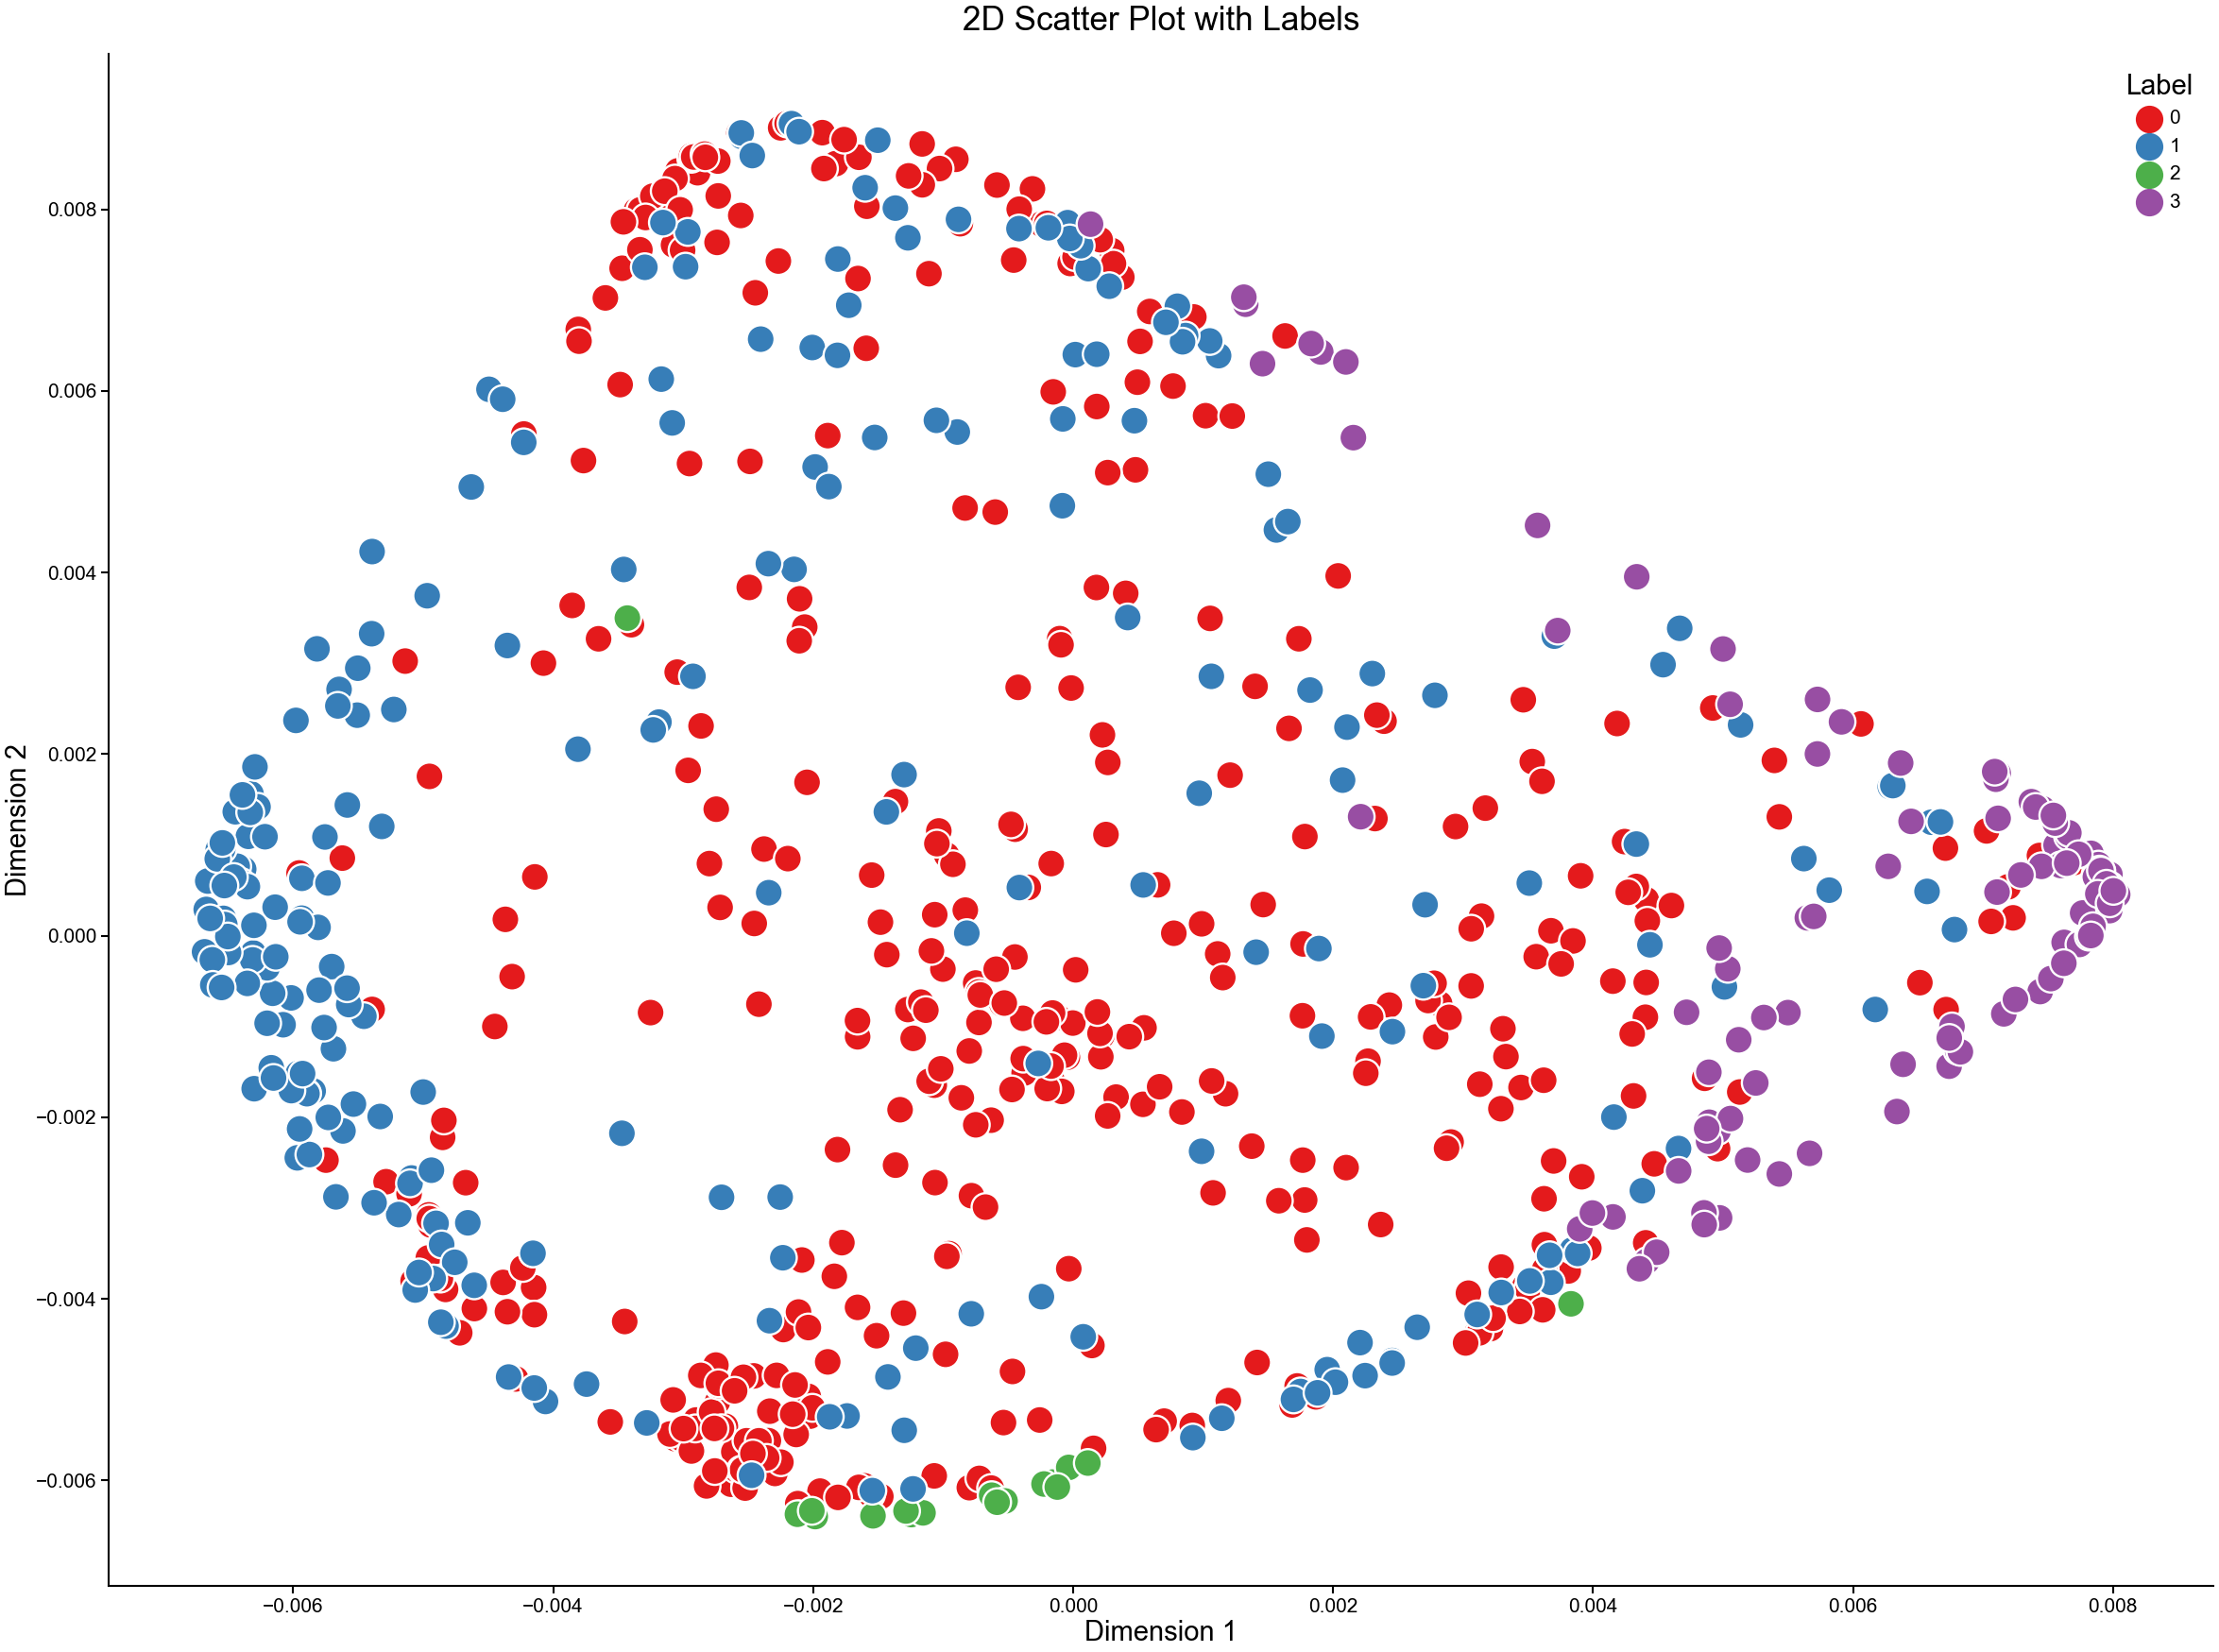

In [87]:

# Assume:
# - `x` is a NumPy array of shape (n_samples, 2) containing your 2D coordinates.
# - `y` is an array-like object of labels (strings or numbers) with length n_samples.

# Create a DataFrame for easier plotting
data = pd.DataFrame({
    'Dimension 1': sz_embeddings_reduced[:, 0],
    'Dimension 2': sz_embeddings_reduced[:, 1],
    'Label': y_tensor.cpu().detach().numpy()
})

# Create the scatterplot, using the 'hue' parameter to color each dot by its label
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Dimension 1', y='Dimension 2', hue='Label', palette='Set1', s=50)

# Optional: improve the plot aesthetics
plt.title('2D Scatter Plot with Labels')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(title='Label')
plt.show()

In [ ]:
sz_lin_trans = model.linear_1(X_tensor).cpu().detach()

sz_embeddings_reduced = reducer.fit_transform(sz_lin_trans)


fig, ax = plt.subplots(1, 1, figsize=(80*MM_TO_IN, 80*MM_TO_IN))
sns.scatterplot(
    x=sz_embeddings_reduced[:, 0],
    y=sz_embeddings_reduced[:, 1],
    alpha=0.8,
    hue = y_tensor.cpu().detach().numpy(),
    s=5,
    ax=ax,
    legend=False)
ax.set_xlabel(f'{reducer_name} 1')
ax.set_ylabel(f'{reducer_name} 2')
ax.set_title(f'{reducer_name} of tokens')
sns.despine()

fig = plt.figure(figsize=(80*MM_TO_IN, 80*MM_TO_IN))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    sz_embeddings_reduced[:, 0],
    sz_embeddings_reduced[:, 1],
    sz_embeddings_reduced[:, 2],
    alpha=0.6,
    c = y_tensor.cpu().detach().numpy(),
    s=2,
    # hue=n_signals[~nan_mask],
)
ax.set_xlabel(f'{reducer_name} 1')
ax.set_ylabel(f'{reducer_name} 2')
ax.set_zlabel(f'{reducer_name} 3')

ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[]

In [101]:
# For Jupyter Notebook: Uncomment one of the following lines at the top of your cell.
# %matplotlib notebook
# %matplotlib widget

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # required for 3D plotting
import torch

# --- Assume these variables are defined ---
# sz_embeddings_reduced3d: NumPy array of shape (n_samples, 3) with your 3D embeddings.
# y_tensor: a PyTorch tensor containing labels (numeric or mapped from categorical labels)
# reducer_name: a string (e.g., "UMAP", "PCA", etc.)
# MM_TO_IN: conversion factor from millimeters to inches (e.g., 0.03937)

# Convert your label tensor to a NumPy array.
y_np = y_tensor.cpu().detach().numpy()

# Optionally, if your y_np are not numeric (or you want specific colors), you can create a color mapping:
# For example, if you have four classes, you can do:
# import numpy as np
# unique_labels = np.unique(y_np)
# cmap = {label: color for label, color in zip(unique_labels, ['red', 'blue', 'green', 'purple'])}
# colors = [cmap[label] for label in y_np]
# Then use: c=colors  (but note that when using a list of colors, you don't specify a colormap)

# --- Create the 3D Plot ---
# If running as a script, you can enable interactive mode:
plt.ion()

fig = plt.figure(figsize=(80 * MM_TO_IN, 80 * MM_TO_IN))
ax = fig.add_subplot(111, projection='3d')

# Use a colormap if your labels are numeric.
sc = ax.scatter(
    sz_embeddings_reduced[:, 0],
    sz_embeddings_reduced[:, 1],
    sz_embeddings_reduced[:, 2],
    s=5,
    alpha=0.6,
    c=y_np,         # now a numeric array of labels
    cmap='viridis', # choose any colormap you prefer
)

# Add a colorbar to show the mapping from numbers to colors.
plt.colorbar(sc, ax=ax)

# Set axis labels
ax.set_xlabel(f'{reducer_name} 1')
ax.set_ylabel(f'{reducer_name} 2')
ax.set_zlabel(f'{reducer_name} 3')

# Remove tick labels if desired
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# Display the plot
plt.show()


<IPython.core.display.Javascript object>